In [2]:
import requests

url = "https://api.elections.kalshi.com/trade-api/v2/markets"
params = {
    "limit": 100,
    "status": "open",
    "series_ticker": "Pro Basketball (M)" # Filter specifically for NBA markets
}

response = requests.get(url, params=params)
data = response.json()

# Parse into a DataFrame
import pandas as pd
df = pd.DataFrame(data['markets'])
print(df[['ticker', 'yes_bid', 'yes_ask', 'no_bid', 'no_ask']])

KeyboardInterrupt: 

In [2]:
pip install sbrscrape

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
from sbrscrape import Scoreboard

# 1. Initialize the Scoreboard for NBA
sb = Scoreboard(sport="NBA")

# 2. Access the games list
# The scraper runs immediately upon initialization
if not hasattr(sb, 'games'):
    print("No games found or scraping failed.")
else:
    for game in sb.games:
        print(f"\n{game['away_team']} @ {game['home_team']}")
        print(f"Status: {game['status']}")
        
        # 3. Access Odds (Moneyline, Spread, Total)
        # sbrscrape returns a dictionary of books for each market
        
        # Example: Print FanDuel ('fanduel') Moneyline if available
        if 'home_ml' in game and 'fanduel' in game['home_ml']:
            fd_home_ml = game['home_ml']['fanduel']
            fd_away_ml = game['away_ml']['fanduel']
            print(f"  FanDuel ML: {game['away_team']} {fd_away_ml} | {game['home_team']} {fd_home_ml}")
            
        # Example: Print Consensus Line
        if 'current_line' in game:
            print(f"  Consensus Spread: {game['current_line'].get('spread', 'N/A')}")


Detroit Pistons @ Charlotte Hornets
Status: 19:00 ET
  FanDuel ML: Detroit Pistons -146 | Charlotte Hornets 124

Milwaukee Bucks @ Orlando Magic
Status: 19:30 ET
  FanDuel ML: Milwaukee Bucks 360 | Orlando Magic -461

Utah Jazz @ Miami Heat
Status: 19:30 ET
  FanDuel ML: Utah Jazz 250 | Miami Heat -319

Chicago Bulls @ Brooklyn Nets
Status: 19:30 ET
  FanDuel ML: Chicago Bulls -168 | Brooklyn Nets 142

Sacramento Kings @ New Orleans Pelicans
Status: 20:00 ET
  FanDuel ML: Sacramento Kings 250 | New Orleans Pelicans -310

Atlanta Hawks @ Minnesota Timberwolves
Status: 20:00 ET
  FanDuel ML: Atlanta Hawks 205 | Minnesota Timberwolves -250

Cleveland Cavaliers @ Denver Nuggets
Status: 21:00 ET
  FanDuel ML: Cleveland Cavaliers -108 | Denver Nuggets -108

Oklahoma City Thunder @ Los Angeles Lakers
Status: 22:00 ET
  FanDuel ML: Oklahoma City Thunder -240 | Los Angeles Lakers 198

Memphis Grizzlies @ Golden State Warriors
Status: 22:00 ET
  FanDuel ML: Memphis Grizzlies 215 | Golden State 

In [ ]:
import time
import pandas as pd
from datetime import date, timedelta
from sbrscrape import Scoreboard

sb = Scoreboard(sport="NBA")

def get_historical_odds(start_date, end_date, sport="NBA"):
    """
    Scrapes historical odds day-by-day from SBR.
    """
    all_games = []
    
    # Generate list of dates
    delta = end_date - start_date
    date_list = [start_date + timedelta(days=i) for i in range(delta.days + 1)]

    print(f"--- Starting Scrape for {len(date_list)} Days ---")

    for current_date in date_list:
        date_str = current_date.strftime("%Y-%m-%d")
        print(f"Scraping {date_str}...", end=" ")
        
        try:
            # Initialize Scoreboard for specific date
            sb = Scoreboard(sport=sport, date=date_str)
            
            if not hasattr(sb, 'games') or not sb.games:
                print("No games found.")
                continue

            # Parse each game found on that day
            for game in sb.games:
                # Basic game info
                row = {
                    "Date": date_str,
                    "Home": game.get('home_team'),
                    "Away": game.get('away_team'),
                    "Home_Score": game.get('home_score'), # SBR often has scores for historical games
                    "Away_Score": game.get('away_score'),
                    "Status": game.get('status')
                }

                # EXTRACT ODDS (Example: FanDuel)
                # You can change 'fanduel' to 'draftkings', 'bovada', etc.
                bookie = 'fanduel'
                
                # Moneyline
                if 'home_ml' in game and bookie in game['home_ml']:
                    row['Home_ML'] = game['home_ml'][bookie]
                    row['Away_ML'] = game['away_ml'][bookie]
                
                # Spread
                if 'home_spread' in game and bookie in game['home_spread']:
                    row['Home_Spread'] = game['home_spread'][bookie]
                    row['Away_Spread'] = game['away_spread'][bookie]
                
                # Total (Over/Under)
                if 'total' in game and bookie in game['total']:
                    row['Total'] = game['total'][bookie]

                all_games.append(row)
            
            print(f"Found {len(sb.games)} games.")
            
        except Exception as e:
            print(f"Error: {e}")

        # CRITICAL: Sleep to avoid IP Ban
        time.sleep(1.75) 

    return pd.DataFrame(all_games)

# --- USAGE ---
# Example: Get odds for the first week of January 2024
s_date = date(2015, 11,22)
e_date = date(2026, 1,24)

df = get_historical_odds(s_date, e_date)
print(df.head())

# Save to CSV for your model
df.to_csv("NBA_BETTING_DATA.csv", index=False)

--- Starting Scrape for 3717 Days ---
Scraping 2015-11-22... Found 6 games.
Scraping 2015-11-23... Found 7 games.
Scraping 2015-11-24... Found 6 games.
Scraping 2015-11-25... Found 12 games.
Scraping 2015-11-26... No games found.
Scraping 2015-11-27... Found 12 games.
Scraping 2015-11-28... Found 7 games.
Scraping 2015-11-29... Found 8 games.
Scraping 2015-11-30... Found 8 games.
Scraping 2015-12-01... Found 6 games.
Scraping 2015-12-02... Found 9 games.
Scraping 2015-12-03... Found 6 games.
Scraping 2015-12-04... Found 6 games.
Scraping 2015-12-05... Found 10 games.
Scraping 2015-12-06... Found 5 games.
Scraping 2015-12-07... Found 9 games.
Scraping 2015-12-08... Found 6 games.
Scraping 2015-12-09... Found 10 games.
Scraping 2015-12-10... Found 4 games.
Scraping 2015-12-11... Found 11 games.
Scraping 2015-12-12... Found 9 games.
Scraping 2015-12-13... Found 4 games.
Scraping 2015-12-14... Found 10 games.
Scraping 2015-12-15... Found 4 games.
Scraping 2015-12-16... Found 12 games.
Scra

In [3]:
df.columns
#cuh = df[df['Home_ML']>=0]
#cuh

NameError: name 'df' is not defined

In [1]:
import pandas as pd
import os

# Configuration
filename = 'NBA_BETTING_DATA.csv'


if os.path.exists(filename):
    existing_df = pd.read_csv(filename)
    print(f"Loaded existing file with {len(existing_df)} rows.")
else:
    existing_df = pd.DataFrame()
    print("Existing file not found. Starting fresh.")


combined_df = pd.concat([existing_df, df], ignore_index=True)


nan_start_len = len(combined_df)
combined_df = combined_df.dropna(subset=['Home_ML'])
nan_dropped_count = nan_start_len - len(combined_df)



initial_len = len(combined_df)
combined_df = combined_df.drop_duplicates(subset=['Date', 'Home'], keep='last')
dropped_dup_count = initial_len - len(combined_df)


combined_df.to_csv(filename, index=False)

print(f"\n--- SUCCESS ---")
print(f"Old Row Count: {len(existing_df)}")
print(f"New Rows Added (Raw): {len(df)}")
print(f"Rows Dropped (Missing Odds): {nan_dropped_count}") # <--- New Report Line
print(f"Duplicates Dropped: {dropped_dup_count}")
print(f"Final Row Count: {len(combined_df)}")
print(f"Saved to: {filename}")

C:\Users\luric\AppData\Local\Temp\ipykernel_15764\2104345885.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_df = pd.read_csv(filename)


Loaded existing file with 24149 rows.


NameError: name 'df' is not defined

In [4]:
df.to_csv("nba_historical_odds_jan2025.csv", index=False)

In [5]:
import sportsdataverse as sdv
import pandas as pd
import numpy as np
import warnings
import gc
import os

warnings.filterwarnings('ignore')
gc.collect()
print("--- STARTING MASTER PIPELINE (SVD + SCRAPED ODDS) ---")


 # SDV usually treats the year as the "Season End Year" (e.g., 2022 = 2021-22 Season)
seasons = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
schedule_list = []
boxscore_list = []
player_box_list = []

print(f"1. Loading SDV Stats for {seasons}...")
for s in seasons:
    try:
        # Load individually to avoid Polars/Arrow schema crashes
        df_s = sdv.nba.load_nba_schedule(seasons=[s], return_as_pandas=True)
        schedule_list.append(df_s)
        
        df_b = sdv.nba.load_nba_team_boxscore(seasons=[s], return_as_pandas=True)
        boxscore_list.append(df_b)
        
        df_pb = sdv.nba.load_nba_player_boxscore(seasons=[s], return_as_pandas=True)
        player_box_list.append(df_pb)
    except Exception as e:
        print(f"   Error loading season {s}: {e}")

nba_sched = pd.concat(schedule_list, axis=0, ignore_index=True)
nba_team_box = pd.concat(boxscore_list, axis=0, ignore_index=True)
nba_player_box = pd.concat(player_box_list, axis=0, ignore_index=True)

# Standardize Dates
for df in [nba_sched, nba_team_box, nba_player_box]:
    if 'game_date' in df.columns:
        df['game_date'] = pd.to_datetime(df['game_date']).dt.normalize()

# Create 'team_abbrev' for merging (SDV uses 'home_abbreviation')
nba_sched['team_abbrev'] = nba_sched['home_abbreviation']

# ==========================================
# 2. FULL FEATURE ENGINEERING (RESTORED ALL FEATURES)
# ==========================================
print("2. Building Full Feature Set (Windows: 2, 4, 8, 10)...")

# A. Opponent Stats & Base Metrics
opp_stats = nba_team_box[['game_id', 'team_id', 'defensive_rebounds', 'team_score', 'field_goals_attempted', 'free_throws_attempted', 'turnovers']].rename(
    columns={'team_id': 'opp_id', 'defensive_rebounds': 'opp_drb', 'team_score': 'opp_score',
             'field_goals_attempted': 'opp_fga', 'free_throws_attempted': 'opp_fta', 'turnovers': 'opp_tov'}
)
nba_team_box = nba_team_box.merge(opp_stats, on='game_id')
nba_team_box = nba_team_box[nba_team_box['team_id'] != nba_team_box['opp_id']]

# Player Talent/Usage Aggregation (RESTORED)
nba_player_box['player_val'] = (nba_player_box['points'] + 0.4 * nba_player_box['field_goals_made'] - 
                                0.7 * nba_player_box['field_goals_attempted'] + 0.5 * nba_player_box['free_throws_made'] + 
                                nba_player_box['steals'] + 0.7 * nba_player_box['assists'])
nba_player_box['player_poss'] = nba_player_box['field_goals_attempted'] + 0.44 * nba_player_box['free_throws_attempted'] + nba_player_box['turnovers']

team_talent_usage = nba_player_box.groupby(['game_id', 'team_id']).agg({'player_val': 'sum', 'player_poss': 'std'}).reset_index().rename(columns={'player_val': 'active_talent_score', 'player_poss': 'usage_std'})
nba_team_box = nba_team_box.merge(team_talent_usage, on=['game_id', 'team_id'], how='left')

# Advanced Team Metrics (RESTORED)
nba_team_box['possessions'] = (nba_team_box['field_goals_attempted'] + 0.44 * nba_team_box['free_throws_attempted'] - nba_team_box['offensive_rebounds'] + nba_team_box['turnovers'])
nba_team_box['off_rating'] = (nba_team_box['team_score'] / nba_team_box['possessions']) * 100
nba_team_box['def_rating'] = (nba_team_box['opp_score'] / nba_team_box['possessions']) * 100
nba_team_box['pace'] = (nba_team_box['possessions'] / 48) * 48 
nba_team_box['efg_pct'] = (nba_team_box['field_goals_made'] + 0.5 * nba_team_box['three_point_field_goals_made']) / nba_team_box['field_goals_attempted']
nba_team_box['ts_pct'] = nba_team_box['team_score'] / (2 * (nba_team_box['field_goals_attempted'] + 0.44 * nba_team_box['free_throws_attempted']))

# B. Rolling Stats Loop (Windows: 2, 4, 8, 10)
nba_team_box = nba_team_box.sort_values(['team_id', 'game_date'])
windows = [2, 4, 8, 10]
metrics = ['off_rating', 'def_rating', 'efg_pct', 'ts_pct', 'pace', 'active_talent_score', 'usage_std']

for w in windows:
    for m in metrics:
        nba_team_box[f'roll_{m}_{w}'] = nba_team_box.groupby('team_id')[m].transform(lambda x: x.shift(1).rolling(w).mean())
    nba_team_box[f'roll_score_std_{w}'] = nba_team_box.groupby('team_id')['team_score'].transform(lambda x: x.shift(1).rolling(w).std())

# C. Schedule & Rest
team_sched = pd.concat([nba_sched[['game_date', 'home_id']].rename(columns={'home_id': 'team_id'}),
                        nba_sched[['game_date', 'away_id']].rename(columns={'away_id': 'team_id'})]).sort_values(['team_id', 'game_date']).drop_duplicates()
team_sched['rest'] = (team_sched.groupby('team_id')['game_date'].diff().dt.days - 1).clip(lower=0).fillna(10)

# D. Build The Base DataFrame
nba_clean = nba_sched[['id', 'game_date', 'home_id', 'away_id', 'home_winner', 'season', 'team_abbrev']].copy()

for side in ['home', 'away']:
    nba_clean = nba_clean.merge(team_sched, left_on=['game_date', f'{side}_id'], right_on=['game_date', 'team_id'], how='left').rename(columns={'rest': f'{side}_rest'}).drop(columns='team_id')
    
    for w in windows:
        for m in metrics + ['score_std']:
            col_name = f'roll_{m}_{w}'
            final_col = f'{side}_{m}_{w}'
            nba_clean = nba_clean.merge(
                nba_team_box[['game_id', 'team_id', col_name]],
                left_on=['id', f'{side}_id'],
                right_on=['game_id', 'team_id'],
                how='left'
            ).rename(columns={col_name: final_col}).drop(columns=['game_id', 'team_id'])

# ==========================================
# 3. LOAD SCRAPED ODDS DATA (FIXED & ROBUST)
# ==========================================
print("3. Processing Scraped Betting Data...")

try:
    # --- UPDATED FILENAME HERE ---
    odds_df = pd.read_csv('NBA_BETTING_DATA.csv') 
    print(f"   Loaded {len(odds_df)} rows from scraped file.")
except FileNotFoundError:
    print("   ERROR: 'NBA_BETTING_DATA.csv' not found. Please check file path.")
    odds_df = pd.DataFrame()

# 3A. FILTER EXHIBITION TEAMS
if not odds_df.empty and 'Home' in odds_df.columns:
    # Filter out anything starting with "Team" (LeBron, Isiah, etc.)
    odds_df = odds_df[~odds_df['Home'].str.startswith('Team', na=False)]
    odds_df = odds_df[~odds_df['Away'].str.startswith('Team', na=False)]
    # Filter out All-Star abbreviations explicitly found in SDV image
    odds_df = odds_df[~odds_df['Home'].isin(['USA', 'GIA', 'DUR', 'LEB', 'EAST', 'CHK', 'SHQ', 'TBD'])]

# 3B. SDV-SPECIFIC MAPPING
SBR_TO_SDV_MAP = {
    # The Mismatches
    'Golden State Warriors': 'GS', 'Golden State': 'GS',
    'San Antonio Spurs': 'SA', 'San Antonio': 'SA',
    'New York Knicks': 'NY', 'New York': 'NY',
    'New Orleans Pelicans': 'NO', 'New Orleans': 'NO',
    'Utah Jazz': 'UTAH', 'Utah': 'UTAH',
    'Washington Wizards': 'WSH', 'Washington': 'WSH',
    
    # The Standards
    'Phoenix Suns': 'PHX', 'Phoenix': 'PHX',
    'Brooklyn Nets': 'BKN', 'Brooklyn': 'BKN',
    'Atlanta Hawks': 'ATL', 'Atlanta': 'ATL',
    'Boston Celtics': 'BOS', 'Boston': 'BOS',
    'Charlotte Hornets': 'CHA', 'Charlotte': 'CHA',
    'Chicago Bulls': 'CHI', 'Chicago': 'CHI',
    'Cleveland Cavaliers': 'CLE', 'Cleveland': 'CLE',
    'Dallas Mavericks': 'DAL', 'Dallas': 'DAL',
    'Denver Nuggets': 'DEN', 'Denver': 'DEN',
    'Detroit Pistons': 'DET', 'Detroit': 'DET',
    'Houston Rockets': 'HOU', 'Houston': 'HOU',
    'Indiana Pacers': 'IND', 'Indiana': 'IND',
    'L.A. Clippers': 'LAC', 'LA Clippers': 'LAC', 'Los Angeles Clippers': 'LAC',
    'L.A. Lakers': 'LAL', 'LA Lakers': 'LAL', 'Los Angeles Lakers': 'LAL',
    'Memphis Grizzlies': 'MEM', 'Memphis': 'MEM',
    'Miami Heat': 'MIA', 'Miami': 'MIA',
    'Milwaukee Bucks': 'MIL', 'Milwaukee': 'MIL',
    'Minnesota Timberwolves': 'MIN', 'Minnesota': 'MIN',
    'Oklahoma City Thunder': 'OKC', 'Oklahoma City': 'OKC',
    'Orlando Magic': 'ORL', 'Orlando': 'ORL',
    'Philadelphia 76ers': 'PHI', 'Philadelphia': 'PHI',
    'Portland Trail Blazers': 'POR', 'Portland': 'POR',
    'Sacramento Kings': 'SAC', 'Sacramento': 'SAC',
    'Toronto Raptors': 'TOR', 'Toronto': 'TOR'
}


if not odds_df.empty:
    # 1. Apply Mapping
    odds_df['team_abbrev'] = odds_df['Home'].map(SBR_TO_SDV_MAP)
    
    print("   Running Data Safety Check...")
    initial_len = len(odds_df)
    
    # Filter A: Remove Impossible Odds (Fixes the -50000 error)
    # We keep only rows where Moneyline is between -10000 and +10000
    if 'Home_ML' in odds_df.columns:
        odds_df = odds_df[
            (odds_df['Home_ML'] > -10000) & (odds_df['Home_ML'] < 10000)
        ]
    
    # Filter B: Remove the "Poisoned" Dates (Before Nov 22, 2021)
    # We assume 'Date' is still a string here, so we convert it temporarily
    #odds_df['temp_date_filter'] = pd.to_datetime(odds_df['Date'])
    #odds_df = odds_df[odds_df['temp_date_filter'] > '2021-11-22']
    #odds_df = odds_df.drop(columns=['temp_date_filter'])
    odds_df['game_date'] = pd.to_datetime(odds_df['Date'], format='%m/%d/%Y', errors='coerce').dt.normalize()
    odds_df = odds_df.dropna(subset=['game_date'])
    dropped_count = initial_len - len(odds_df)
    print(f"   [CLEANUP] Dropped {dropped_count} rows of bad/early data.")
    
    # 2. CRASH FIX: Drop 'game_date' if it already exists from a previous run
    if 'game_date' in odds_df.columns:
        odds_df = odds_df.drop(columns=['game_date'])
        
    # 3. Rename Date -> game_date
    if 'Date' in odds_df.columns:
        odds_df['game_date'] = pd.to_datetime(odds_df['Date']).dt.normalize()

    # 4. Implied Probabilities
    def american_to_prob(ml):
        if pd.isna(ml) or ml == 0: return 0.5
        return 100 / (ml + 100) if ml > 0 else abs(ml) / (abs(ml) + 100)
    
    if 'Home_ML' in odds_df.columns:
        odds_df['home_market_prob'] = odds_df['Home_ML'].apply(american_to_prob)
        odds_df['away_market_prob'] = odds_df['Away_ML'].apply(american_to_prob)
    
    # 5. Rename Columns
    col_renames = {'Home_Spread': 'spread', 'Total': 'total'}
    odds_df = odds_df.rename(columns={k:v for k,v in col_renames.items() if k in odds_df.columns})
    
    # 6. Clean
    odds_df = odds_df.dropna(subset=['team_abbrev', 'game_date'])
    print(f"   Odds Data Ready: {len(odds_df)} clean rows.")

# ==========================================
# 4. THE SMART MERGE (FIXED SHIFT)
# ==========================================
print("4. Merging Stats + Scraped Odds (Smart Method)...")

if not odds_df.empty:
    # 1. Create Shifted Copies
    odds_day_0 = odds_df.copy()
    odds_day_minus_1 = odds_df.copy()
    odds_day_minus_1['game_date'] = odds_day_minus_1['game_date'] + pd.Timedelta(days=1)
    
    # 2. Select Columns
    betting_cols = ['spread', 'total', 'home_market_prob', 'away_market_prob']
    available_cols = [c for c in betting_cols if c in odds_df.columns]
    merge_cols = ['game_date', 'team_abbrev'] + available_cols

    # 3. Attempt 1: Exact Match
    merged_0 = nba_clean.merge(odds_day_0[merge_cols], on=['game_date', 'team_abbrev'], how='left')

    # 4. Attempt 2: Fill missing with Shifted Data
    missing_mask = merged_0['home_market_prob'].isna()
    missing_rows = nba_clean.loc[missing_mask].copy()
    
    filled_minus_1 = missing_rows.merge(
        odds_day_minus_1[merge_cols],
        on=['game_date', 'team_abbrev'],
        how='left',
        suffixes=('', '_new')
    )
    
    merged_0.loc[missing_mask, available_cols] = filled_minus_1[available_cols].values
    nba_model_ready = merged_0.copy()

    # Derived Feature
    if 'home_market_prob' in nba_model_ready.columns:
        nba_model_ready['market_prob_diff'] = nba_model_ready['home_market_prob'] - nba_model_ready['away_market_prob']

else:
    nba_model_ready = nba_clean.copy()

# Net Rating Diff
nba_model_ready['net_rtg_diff'] = (nba_model_ready['home_off_rating_10'] - nba_model_ready['home_def_rating_10']) - (nba_model_ready['away_off_rating_10'] - nba_model_ready['away_def_rating_10'])

# Final Filter
nba_model_ready = nba_model_ready.dropna(subset=['home_winner']).sort_values('game_date')

# 5. REPORT
success_count = nba_model_ready['home_market_prob'].notna().sum() if 'home_market_prob' in nba_model_ready.columns else 0
print("\n--- PIPELINE COMPLETE ---")
print(f"Total Games: {len(nba_model_ready)}")
print(f"Games with Betting Data: {success_count}")
print(f"Success Rate: {success_count/len(nba_model_ready):.1%}")

if success_count > 0:
    print("\nSample Data (First 3 rows):")
    print(nba_model_ready[['game_date', 'team_abbrev', 'home_market_prob', 'spread']].dropna().head(3))

--- STARTING MASTER PIPELINE (SVD + SCRAPED ODDS) ---
1. Loading SDV Stats for [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]...


100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


2. Building Full Feature Set (Windows: 2, 4, 8, 10)...
3. Processing Scraped Betting Data...
   Loaded 24149 rows from scraped file.
   Running Data Safety Check...
   [CLEANUP] Dropped 150 rows of bad/early data.
   Odds Data Ready: 23999 clean rows.
4. Merging Stats + Scraped Odds (Smart Method)...

--- PIPELINE COMPLETE ---
Total Games: 25247
Games with Betting Data: 23349
Success Rate: 92.5%

Sample Data (First 3 rows):
      game_date team_abbrev  home_market_prob  spread
2626 2007-10-30          SA           0.10000    13.0
2625 2007-10-30         LAL           0.69697    -5.0
2624 2007-10-30          GS           0.50000     1.0


In [6]:
# 1. Filter for rows where betting data is missing
missing_bets = nba_model_ready[nba_model_ready['home_market_prob'].isna()]

print(f"Total Games Missing Odds: {len(missing_bets)}")

# 2. Show a sample of the missing games (Date + Teams)
print("\n--- Sample of Missing Games ---")
print(missing_bets[['game_date', 'team_abbrev', 'home_winner']].head(10))

# 3. DIAGNOSIS: Is it specific teams?
print("\n--- Missing Count by Team (Are some abbreviations broken?) ---")
print(missing_bets['team_abbrev'].value_counts().head(5))

# 4. DIAGNOSIS: Is it specific seasons/years?
print("\n--- Missing Count by Season/Year ---")
# Extract year from game_date for grouping
missing_bets['year'] = missing_bets['game_date'].dt.year
print(missing_bets['year'].value_counts().sort_index())

Total Games Missing Odds: 1898

--- Sample of Missing Games ---
      game_date team_abbrev home_winner
1308 2006-10-31         MIA       False
1309 2006-10-31         LAL        True
1295 2006-11-01         PHX        True
1296 2006-11-01         CLE        True
1297 2006-11-01         DET       False
1298 2006-11-01         BOS       False
1299 2006-11-01          GS       False
1307 2006-11-01         CHA       False
1301 2006-11-01         MIN        True
1302 2006-11-01         ORL        True

--- Missing Count by Team (Are some abbreviations broken?) ---
team_abbrev
NJ      244
SEA      82
PHX      64
GS       61
UTAH     60
Name: count, dtype: int64

--- Missing Count by Season/Year ---
year
2006    456
2007    888
2008     67
2009     41
2010     42
2011     28
2012     33
2013      1
2014      1
2015      1
2016      1
2017      1
2018      2
2019     36
2020      4
2021    108
2022      2
2023      2
2024     14
2025      3
2026    167
Name: count, dtype: int64


In [8]:
nba_model_ready.to_csv("NBA_MODEL_READY_DATA.csv", index=False)

In [1]:
import pandas as pd

nba_model_ready = pd.read_csv("NBA_MODEL_READY_DATA.csv", parse_dates=['game_date'])

In [4]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import time
import gc  # Garbage collection to prevent the 1000s hang

# 1. PARAMETERS
BATCH_SIZE = 10 
DECAY_RATE = 0.0025 # xi parameter for decay (0.0065 is Dixon-Coles standard)
advanced_metrics = [
    'home_off_rating_10', 'away_off_rating_10',
    'home_def_rating_10', 'away_def_rating_10',
    'home_efg_pct_10', 'away_efg_pct_10',
    'home_ts_pct_10', 'away_ts_pct_10',         # New: Scoring Efficiency
    'home_tov_rate_10', 'away_tov_rate_10',
    'home_orb_pct_10', 'away_orb_pct_10',
    'home_ft_rate_10', 'away_ft_rate_10',
    'home_pace_10', 'away_pace_10',             # New: Game Tempo
    'home_active_talent_score_10', 'away_active_talent_score_10',
    'home_usage_std_10', 'away_usage_std_10',   # New: Offensive Balance
    'home_assists_10', 'away_assists_10',
    'home_steals_10', 'away_steals_10'
]

# 2. Enhanced features (Baseline & Stability)
enhanced_features = [
    'home_score_std_10', 'away_score_std_10',
    'home_streak', 'away_streak',
    'home_rest', 'away_rest',
    'h2h_win_rate', 'h2h_games'
]

# 3. Differential/derived features
# Added ts_diff and pace_diff to capture relative advantages
differential_features = [
    'net_rtg_diff', 
    'ts_diff_10',      # New: Efficiency Delta
    'pace_diff_10',    # New: Tempo Delta
    'talent_diff_10', 
    'rest_advantage', 
    'streak_diff', 
    'consistency_diff',
    'home_momentum', 'away_momentum', 'momentum_diff',
    'talent_x_rest', 'streak_x_momentum'
]

# 4. Situational flags
situational_features = [
    'home_b2b', 'away_b2b', 'both_rested'
]

# 5. Dynamic Rolling Features (Captures all windows: 2, 4, 8, 10)
rolling_features = [c for c in nba_model_ready.columns if any(x in c for x in ['_2', '_4', '_8', '_10']) and 'roll' in c]

# Combine, remove duplicates, and verify presence in the dataframe
feature_cols = rolling_features + advanced_metrics + enhanced_features + differential_features + situational_features
feature_cols = [c for c in dict.fromkeys(feature_cols) if c in nba_model_ready.columns]
#feature_cols = [c for c in dict.fromkeys(feature_cols) if c in training_data.columns]

# 2. PREPARE DATA STREAM
# Sort and ensure datetime format
full_stream = nba_model_ready.sort_values(['game_date', 'id']).reset_index(drop=True)
#full_stream = training_data.sort_values(['game_date', 'id']).reset_index(drop=True)
full_stream['game_date'] = pd.to_datetime(full_stream['game_date'])

# Convert to Float32 Contiguous Numpy for hardware speed
full_values = np.ascontiguousarray(full_stream[feature_cols].values.astype('float32'))
full_labels = full_stream['home_winner'].astype(int).values
full_dates = full_stream['game_date'].values

# Start predictions after x season
start_index = full_stream[full_stream['season'] < 2025].shape[0]

# 3. XGBOOST CONFIG
params = {
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'max_depth': 4,
    'learning_rate': 0.03,
    'nthread': 1,  # Single-thread prevents the coordination deadlock
    'verbosity': 0
}

In [5]:
# Initialize results and iteration tracking
predictions, actuals, probs, game_num = [], [], [], []
best_iters = [] 
total_start_time = time.time()

print(f"Starting Dynamic Early-Stopping Loop...")

# 4. THE DYNAMIC TIMED & CLEANED LOOP
for i in range(start_index, len(full_stream), BATCH_SIZE):
    batch_start = time.time()
    current_prediction_date = full_dates[i]
    
    # --- TEMPORAL SPLIT FOR EARLY STOPPING ---
    # 80% Train / 20% Eval (the 20% is the most recent data prior to game 'i')
    split_idx = int(i * 0.85)
    
    X_train, y_train = full_values[0:split_idx], full_labels[0:split_idx]
    X_eval, y_eval = full_values[split_idx:i], full_labels[split_idx:i]
    
    train_dates = full_dates[0:split_idx]
    eval_dates = full_dates[split_idx:i]
    
    # --- CALCULATE EXPONENTIAL WEIGHTS ---
    w_train = np.exp(-DECAY_RATE * ((current_prediction_date - train_dates).astype('timedelta64[D]').astype(int) / 7))
    w_eval = np.exp(-DECAY_RATE * ((current_prediction_date - eval_dates).astype('timedelta64[D]').astype(int) / 7))
    
    # --- DMATRIX CREATION ---
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
    deval = xgb.DMatrix(X_eval, label=y_eval, weight=w_eval)
    
    # --- TRAIN WITH EARLY STOPPING ---
    bst = xgb.train(
        params, 
        dtrain, 
        num_boost_round=500, 
        evals=[(dtrain, 'train'), (deval, 'eval')],
        early_stopping_rounds=10,
        verbose_eval=False
    )
    
    # CAPTURE BEST ITERATION BEFORE CLEANUP
    current_best_iter = bst.best_iteration
    best_iters.append(current_best_iter)
    
    # --- PREDICT ---
    end_idx = min(i + BATCH_SIZE, len(full_stream))
    dtest = xgb.DMatrix(full_values[i : end_idx])
    
    # Use the best_iteration to generate the prediction
    batch_probs = bst.predict(dtest, iteration_range=(0, current_best_iter + 1))

    # --- RECORDING ---
    for idx, p in enumerate(batch_probs):
        if p > 0.55 or p < 0.45:
            predictions.append(1 if p > 0.55 else 0)
            actuals.append(full_labels[i + idx])
            probs.append(p)
            game_num.append(i + idx - start_index)
    
    # --- LOGGING (Before Deletion) ---
    elapsed = time.time() - batch_start
    if (i - start_index) % 10 == 0 and len(predictions) > 0:
        current_acc = accuracy_score(actuals, predictions)
        if len(predictions) >= 50:
            recent_acc = accuracy_score(actuals[-50:], predictions[-50:])
            recent_str = f" | Recent 50: {recent_acc:.2%}"
        else:
            recent_str = ""
        print(f"Game {i}: {elapsed:.2f}s | Cum Acc: {current_acc:.2%}{recent_str} | Iter: {current_best_iter}")
        
    # --- MEMORY CLEANUP ---
    del dtrain, deval, dtest, bst
    gc.collect() 

# 5. FINAL RESULTS
print(f"\nTotal Time: {(time.time() - total_start_time)/60:.2f} minutes")
if len(predictions) > 0:
    print(f"Final Accuracy: {accuracy_score(actuals, predictions):.2%}")

Starting Dynamic Early-Stopping Loop...
Game 23127: 0.21s | Cum Acc: 60.00% | Iter: 116
Game 23137: 0.21s | Cum Acc: 66.67% | Iter: 111
Game 23147: 0.22s | Cum Acc: 66.67% | Iter: 139
Game 23157: 0.19s | Cum Acc: 65.22% | Iter: 119
Game 23167: 0.19s | Cum Acc: 65.52% | Iter: 109
Game 23177: 0.22s | Cum Acc: 63.16% | Iter: 138
Game 23187: 0.18s | Cum Acc: 62.22% | Iter: 104
Game 23197: 0.19s | Cum Acc: 64.00% | Recent 50: 64.00% | Iter: 112
Game 23207: 0.18s | Cum Acc: 65.00% | Recent 50: 64.00% | Iter: 112
Game 23217: 0.21s | Cum Acc: 65.15% | Recent 50: 64.00% | Iter: 134
Game 23227: 0.20s | Cum Acc: 66.22% | Recent 50: 68.00% | Iter: 125
Game 23237: 0.21s | Cum Acc: 65.85% | Recent 50: 68.00% | Iter: 138
Game 23247: 0.19s | Cum Acc: 68.13% | Recent 50: 72.00% | Iter: 111
Game 23257: 0.19s | Cum Acc: 68.32% | Recent 50: 72.00% | Iter: 113
Game 23267: 0.23s | Cum Acc: 66.97% | Recent 50: 70.00% | Iter: 154
Game 23277: 0.22s | Cum Acc: 68.38% | Recent 50: 72.00% | Iter: 150
Game 23287: 

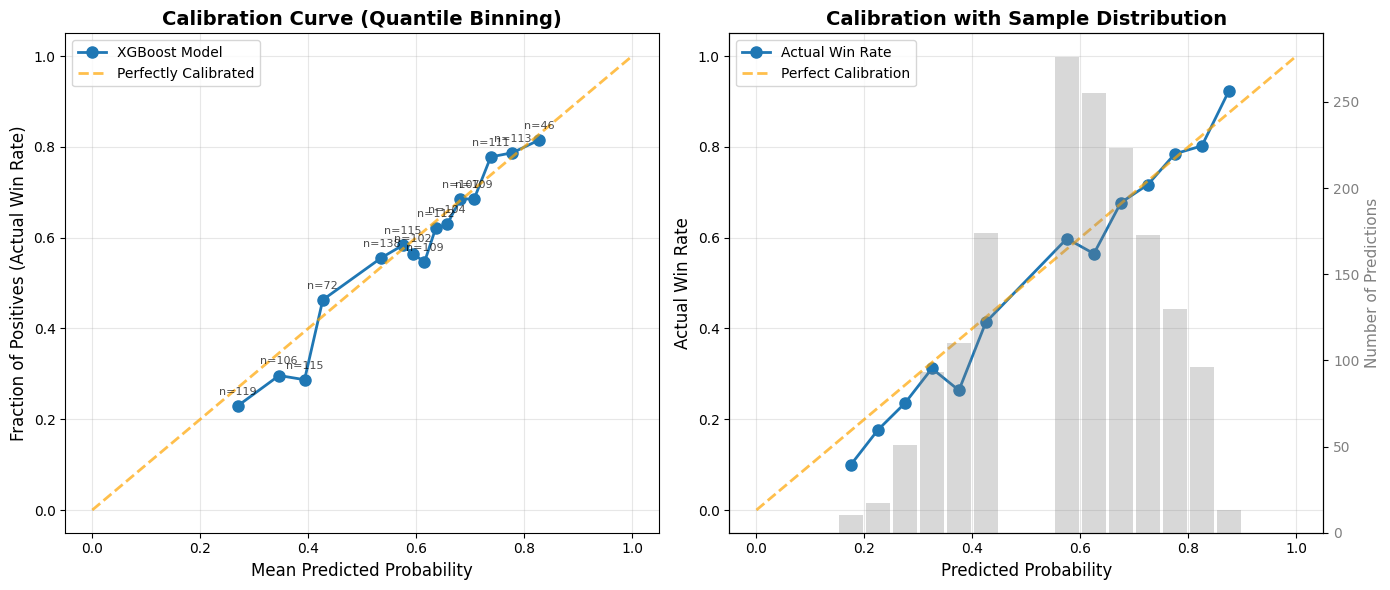


CALIBRATION ANALYSIS BY PROBABILITY RANGE

Very Low Confidence       [0.00 - 0.30]
  Count:                78
  Mean Predicted:     0.254
  Actual Win Rate:    0.205
  Calibration Error:  0.049

Low Confidence            [0.30 - 0.45]
  Count:               377
  Mean Predicted:     0.385
  Actual Win Rate:    0.345
  Calibration Error:  0.041

Toss-up                   [0.45 - 0.55]
  No predictions in this range

Moderate Confidence       [0.55 - 0.70]
  Count:               754
  Mean Predicted:     0.621
  Actual Win Rate:    0.610
  Calibration Error:  0.011

High Confidence           [0.70 - 0.85]
  Count:               399
  Mean Predicted:     0.763
  Actual Win Rate:    0.759
  Calibration Error:  0.003

Very High Confidence      [0.85 - 0.95]
  Count:                13
  Mean Predicted:     0.868
  Actual Win Rate:    0.923
  Calibration Error:  0.055

Extreme Confidence        [0.95 - 1.00]
  No predictions in this range



In [7]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Convert to arrays if not already
probs_array = np.array(probs)
actuals_array = np.array(actuals)

# Create figure with multiple visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== PLOT 1: Traditional Calibration Curve with More Bins =====
ax1 = axes[0]

# Use more bins and quantile strategy for better distribution
fraction_of_positives, mean_predicted_value = calibration_curve(
    actuals_array, 
    probs_array, 
    n_bins=15,  # More bins for granularity
    strategy='quantile'  # Each bin has roughly equal number of samples
)

ax1.plot(mean_predicted_value, fraction_of_positives, 'o-', 
         linewidth=2, markersize=8, label='XGBoost Model')
ax1.plot([0, 1], [0, 1], '--', color='orange', linewidth=2, 
         label='Perfectly Calibrated', alpha=0.7)

# Add count labels to each point
for i, (x, y) in enumerate(zip(mean_predicted_value, fraction_of_positives)):
    # Count samples in this bin
    if i < len(mean_predicted_value) - 1:
        mask = (probs_array >= mean_predicted_value[i]) & (probs_array < mean_predicted_value[i+1])
    else:
        mask = probs_array >= mean_predicted_value[i]
    count = mask.sum()
    ax1.annotate(f'n={count}', (x, y), textcoords="offset points", 
                xytext=(0,8), ha='center', fontsize=8, alpha=0.7)

ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
ax1.set_ylabel('Fraction of Positives (Actual Win Rate)', fontsize=12)
ax1.set_title('Calibration Curve (Quantile Binning)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.05, 1.05])

# ===== PLOT 2: Histogram + Calibration by Fixed Bins =====
ax2 = axes[1]

# Create fixed bins
bins = np.linspace(0, 1, 21)  # 20 bins of width 0.05
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calculate actual win rate and count per bin
bin_accs = []
bin_counts = []

for i in range(len(bins) - 1):
    mask = (probs_array >= bins[i]) & (probs_array < bins[i+1])
    count = mask.sum()
    bin_counts.append(count)
    
    if count > 0:
        acc = actuals_array[mask].mean()
        bin_accs.append(acc)
    else:
        bin_accs.append(np.nan)

# Plot histogram (bars)
ax2_hist = ax2.twinx()
ax2_hist.bar(bin_centers, bin_counts, width=0.045, alpha=0.3, 
             color='gray', label='# Predictions')
ax2_hist.set_ylabel('Number of Predictions', fontsize=11, color='gray')
ax2_hist.tick_params(axis='y', labelcolor='gray')

# Plot calibration line
valid_mask = ~np.isnan(bin_accs)
ax2.plot(bin_centers[valid_mask], np.array(bin_accs)[valid_mask], 
         'o-', linewidth=2, markersize=8, color='#1f77b4', label='Actual Win Rate')
ax2.plot([0, 1], [0, 1], '--', color='orange', linewidth=2, 
         label='Perfect Calibration', alpha=0.7)

ax2.set_xlabel('Predicted Probability', fontsize=12)
ax2.set_ylabel('Actual Win Rate', fontsize=12)
ax2.set_title('Calibration with Sample Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('calibration_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== NUMERICAL SUMMARY =====
print("\n" + "="*60)
print("CALIBRATION ANALYSIS BY PROBABILITY RANGE")
print("="*60)

ranges = [
    (0.0, 0.3, "Very Low Confidence"),
    (0.3, 0.45, "Low Confidence"),
    (0.45, 0.55, "Toss-up"),
    (0.55, 0.7, "Moderate Confidence"),
    (0.7, 0.85, "High Confidence"),
    (0.85, 0.95, "Very High Confidence"),
    (0.95, 1.0, "Extreme Confidence")
]

for low, high, label in ranges:
    mask = (probs_array >= low) & (probs_array <= high)
    count = mask.sum()
    
    if count > 0:
        actual_rate = actuals_array[mask].mean()
        pred_mean = probs_array[mask].mean()
        calibration_error = abs(actual_rate - pred_mean)
        
        print(f"\n{label:25s} [{low:.2f} - {high:.2f}]")
        print(f"  Count:              {count:4d}")
        print(f"  Mean Predicted:     {pred_mean:.3f}")
        print(f"  Actual Win Rate:    {actual_rate:.3f}")
        print(f"  Calibration Error:  {calibration_error:.3f}")
    else:
        print(f"\n{label:25s} [{low:.2f} - {high:.2f}]")
        print(f"  No predictions in this range")

print("\n" + "="*60)

In [8]:
# Initialize results and iteration tracking (LOGISTIC REGRESSION VERSION)
import numpy as np
import time
import gc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# --- CONFIG ---
CONF_HI, CONF_LO = 0.55, 0.45
C_GRID = [0.03, 0.1, 0.3, 1.0, 3.0]

def exp_weekly_decay_weights(current_date, past_dates, decay_rate):
    delta_days = (current_date - past_dates).astype("timedelta64[D]").astype(int)
    delta_weeks = delta_days / 7.0
    return np.exp(-decay_rate * delta_weeks).astype(np.float32)

predictions, actuals, probs, game_num = [], [], [], []
best_cs, best_eval_lls = [], []
total_start_time = time.time()

# --- DEBUG TRACKERS ---
batches = 0
total_tested = 0
min_p, max_p = 1.0, 0.0

print("Starting Logistic Regression dynamic loop...")

for i in range(start_index, len(full_stream), BATCH_SIZE):
    batch_start = time.time()
    current_prediction_date = full_dates[i]

    # --- TEMPORAL SPLIT (85% train / 15% eval, eval is most recent prior to i) ---
    split_idx = int(i * 0.85)
    if split_idx < 200 or (i - split_idx) < 50:
        continue

    X_train, y_train = full_values[:split_idx], full_labels[:split_idx]
    X_eval,  y_eval  = full_values[split_idx:i], full_labels[split_idx:i]

    train_dates = full_dates[:split_idx]
    eval_dates  = full_dates[split_idx:i]

    # --- EXPONENTIAL DECAY WEIGHTS (weekly) ---
    w_train = exp_weekly_decay_weights(current_prediction_date, train_dates, DECAY_RATE)
    w_eval  = exp_weekly_decay_weights(current_prediction_date, eval_dates,  DECAY_RATE)

    # --- SELECT BEST C BY WEIGHTED LOG LOSS ON EVAL ---
    best_C, best_ll, best_model = None, np.inf, None

    for C in C_GRID:
        try:
            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="saga",
                max_iter=2000,
                n_jobs=1,
                random_state=42
            )
            model.fit(X_train, y_train, sample_weight=w_train)

            p_eval = model.predict_proba(X_eval)[:, 1]
            ll = log_loss(y_eval, p_eval, sample_weight=w_eval, labels=[0, 1])

            if ll < best_ll:
                best_ll, best_C, best_model = ll, C, model
        except Exception:
            continue

    if best_model is None:
        continue

    best_cs.append(best_C)
    best_eval_lls.append(best_ll)

    # --- PREDICT NEXT BATCH ---
    end_idx = min(i + BATCH_SIZE, len(full_stream))
    p_batch = best_model.predict_proba(full_values[i:end_idx])[:, 1]

    # --- DEBUG DISTRIBUTION ---
    batches += 1
    total_tested += len(p_batch)
    min_p = min(min_p, float(np.min(p_batch)))
    max_p = max(max_p, float(np.max(p_batch)))

    # uncomment if you want to see probability spread per batch:
    # print("p_batch quantiles:", np.quantile(p_batch, [0.01,0.05,0.25,0.5,0.75,0.95,0.99]))

    # --- RECORD ONLY CONFIDENT PREDICTIONS ---
    for idx, p in enumerate(p_batch):
        if (p > CONF_HI) or (p < CONF_LO):
            predictions.append(1 if p > 0.5 else 0)
            actuals.append(full_labels[i + idx])
            probs.append(float(p))
            game_num.append(i + idx - start_index)

    # --- LOGGING ---
    elapsed = time.time() - batch_start
    if (i - start_index) % 10 == 0:
        if len(predictions) > 0:
            current_acc = accuracy_score(actuals, predictions)
            if len(predictions) >= 50:
                recent_acc = accuracy_score(actuals[-50:], predictions[-50:])
                recent_str = f" | Recent 50: {recent_acc:.2%}"
            else:
                recent_str = ""
            print(f"Game {i}: {elapsed:.2f}s | Cum Acc: {current_acc:.2%}{recent_str} | Best C: {best_C} | Eval LL: {best_ll:.4f}")
        else:
            print(f"Game {i}: {elapsed:.2f}s | No confident preds yet | Best C: {best_C} | Eval LL: {best_ll:.4f}")

    # --- MEMORY CLEANUP ---
    del best_model
    gc.collect()

# --- FINAL RESULTS ---
print(f"\nTotal Time: {(time.time() - total_start_time)/60:.2f} minutes")
print(f"batches: {batches} | total_tested: {total_tested} | min_p/max_p: {min_p:.4f}/{max_p:.4f}")

if len(predictions) > 0:
    print(f"Final Accuracy (confident only): {accuracy_score(actuals, predictions):.2%}")
else:
    print("[LR] No confident predictions recorded.")

Starting Logistic Regression dynamic loop...

Total Time: 0.00 minutes
batches: 0 | total_tested: 0 | min_p/max_p: 1.0000/0.0000
[LR] No confident predictions recorded.


In [9]:
# ============================
# METHOD 2: Random Forest (sklearn) with dynamic hyperparameter selection on eval set
# - Same goal: rolling/streaming training with exponential time-decay weights
# - Uses an 85/15 temporal split for train/eval each step
# - Predicts in batches, records only confident bets (p > 0.55 or < 0.45)
# ============================

import numpy as np
import time
import gc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

# Assumes: full_values, full_labels, full_dates, full_stream, start_index, BATCH_SIZE, DECAY_RATE

CONF_HI, CONF_LO = 0.55, 0.45

def exp_weekly_decay_weights(current_date, past_dates, decay_rate):
    delta_days = (current_date - past_dates).astype("timedelta64[D]").astype(int)
    delta_weeks = delta_days / 7.0
    return np.exp(-decay_rate * delta_weeks).astype(np.float32)

predictions_rf, actuals_rf, probs_rf, game_num_rf = [], [], [], []
total_start_time = time.time()

print("Starting Random Forest dynamic loop...")

# A small candidate set (keeps this from being insanely slow)
RF_GRID = [
    {"n_estimators": 300, "max_depth": 6,  "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 8,  "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 10, "min_samples_leaf": 3,  "max_features": "sqrt"},
    {"n_estimators": 700, "max_depth": 10, "min_samples_leaf": 2,  "max_features": "log2"},
]

for i in range(start_index, len(full_stream), BATCH_SIZE):
    batch_start = time.time()
    current_date = full_dates[i]

    split_idx = int(i * 0.85)
    if split_idx < 500:  # RF needs more data to be stable
        continue

    X_train, y_train = full_values[:split_idx], full_labels[:split_idx]
    X_eval,  y_eval  = full_values[split_idx:i], full_labels[split_idx:i]

    train_dates = full_dates[:split_idx]
    eval_dates  = full_dates[split_idx:i]

    w_train = exp_weekly_decay_weights(current_date, train_dates, DECAY_RATE)
    w_eval  = exp_weekly_decay_weights(current_date, eval_dates,  DECAY_RATE)

    best_cfg, best_ll, best_model = None, np.inf, None

    for cfg in RF_GRID:
        try:
            model = RandomForestClassifier(
                n_estimators=cfg["n_estimators"],
                max_depth=cfg["max_depth"],
                min_samples_leaf=cfg["min_samples_leaf"],
                max_features=cfg["max_features"],
                n_jobs=1,
                random_state=42,
                bootstrap=True
            )
            model.fit(X_train, y_train, sample_weight=w_train)

            p_eval = model.predict_proba(X_eval)[:, 1]
            ll = log_loss(y_eval, p_eval, sample_weight=w_eval, labels=[0, 1])

            if ll < best_ll:
                best_ll, best_cfg, best_model = ll, cfg, model
        except Exception:
            continue

    if best_model is None:
        continue

    end_idx = min(i + BATCH_SIZE, len(full_stream))
    p_batch = best_model.predict_proba(full_values[i:end_idx])[:, 1]

    for j, p in enumerate(p_batch):
        if (p > CONF_HI) or (p < CONF_LO):
            predictions_rf.append(1 if p > 0.5 else 0)
            actuals_rf.append(full_labels[i + j])
            probs_rf.append(float(p))
            game_num_rf.append(i + j - start_index)

    if (i - start_index) % 10 == 0 and len(predictions_rf) > 0:
        acc = accuracy_score(actuals_rf, predictions_rf)
        recent = accuracy_score(actuals_rf[-50:], predictions_rf[-50:]) if len(predictions_rf) >= 50 else None
        elapsed = time.time() - batch_start
        recent_str = f" | Recent 50: {recent:.2%}" if recent is not None else ""
        print(f"Game {i}: {elapsed:.2f}s | Cum Acc: {acc:.2%}{recent_str} | Best RF: {best_cfg} | Eval LL: {best_ll:.4f}")

    del best_model
    gc.collect()

print(f"\n[RF] Total Time: {(time.time() - total_start_time)/60:.2f} minutes")
if len(predictions_rf) > 0:
    print(f"[RF] Final Accuracy: {accuracy_score(actuals_rf, predictions_rf):.2%}")
else:
    print("[RF] No confident predictions recorded.")

Starting Random Forest dynamic loop...
Game 23127: 58.01s | Cum Acc: 57.14% | Best RF: {'n_estimators': 700, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'log2'} | Eval LL: 0.6480
Game 23137: 60.23s | Cum Acc: 64.29% | Best RF: {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'} | Eval LL: 0.6471


KeyboardInterrupt: 

In [ ]:
## With betting data
## Now analyzing with betting data
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import time
import gc

# 1. PARAMETERS & SETUP
BATCH_SIZE = 10
#DECAY_RATE = 0.0025  # Controls how fast old games lose importance
#
# 
#  = 0.05
DECAY_RATE = np.arange(0.005, 0.08, 0.005)
CONFIDENCE_THRESHOLD_HIGH = 0.55
CONFIDENCE_THRESHOLD_LOW = 0.45

# 2. DEFINE FEATURE COLUMNS (DYNAMICALLY)
# We want to grab every feature that isn't ID/Metadata or the Target
exclude_cols = [
    'id', 'game_date', 'home_id', 'away_id', 'home_winner', 
    'season', 'team_abbrev', 'merge_key'
]

# Automatically select all numeric features available in your dataset
feature_cols = [c for c in nba_model_ready.columns if c not in exclude_cols]

# 3. VERIFY & CLEAN
# Ensure we only have numeric types (float/int)
# This prevents errors if any object-type columns slipped in
valid_features = []
for col in feature_cols:
    if pd.api.types.is_numeric_dtype(nba_model_ready[col]):
        valid_features.append(col)
    else:
        print(f"Skipping non-numeric column: {col}")

feature_cols = valid_features

print(f"Feature List Created: {len(feature_cols)} features ready.")

# 4. XGBOOST PARAMS
params = {
    'objective': 'binary:logistic',
    'tree_method': 'hist',   # Faster for continuous training
    'max_depth': 4,
    'learning_rate': 0.03,
    'nthread': 1,            # Single thread for sequential loop
    'verbosity': 0,
    'eval_metric': 'logloss'
}

print(f"Setup Complete. Feature count: {len(feature_cols)}")

Feature List Created: 72 features ready.
Setup Complete. Feature count: 72


In [11]:
feature_cols

['home_rest',
 'home_off_rating_2',
 'home_def_rating_2',
 'home_efg_pct_2',
 'home_ts_pct_2',
 'home_pace_2',
 'home_active_talent_score_2',
 'home_usage_std_2',
 'home_score_std_2',
 'home_off_rating_4',
 'home_def_rating_4',
 'home_efg_pct_4',
 'home_ts_pct_4',
 'home_pace_4',
 'home_active_talent_score_4',
 'home_usage_std_4',
 'home_score_std_4',
 'home_off_rating_8',
 'home_def_rating_8',
 'home_efg_pct_8',
 'home_ts_pct_8',
 'home_pace_8',
 'home_active_talent_score_8',
 'home_usage_std_8',
 'home_score_std_8',
 'home_off_rating_10',
 'home_def_rating_10',
 'home_efg_pct_10',
 'home_ts_pct_10',
 'home_pace_10',
 'home_active_talent_score_10',
 'home_usage_std_10',
 'home_score_std_10',
 'away_rest',
 'away_off_rating_2',
 'away_def_rating_2',
 'away_efg_pct_2',
 'away_ts_pct_2',
 'away_pace_2',
 'away_active_talent_score_2',
 'away_usage_std_2',
 'away_score_std_2',
 'away_off_rating_4',
 'away_def_rating_4',
 'away_efg_pct_4',
 'away_ts_pct_4',
 'away_pace_4',
 'away_active_tal

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
import time
import gc

# --- CONFIGURATION ---
BATCH_SIZE = 10
# We test a range of decay rates to see how "memory" affects calibration
decay_rates_to_test = np.arange(0.005, 0.08, 0.005) 

# 1. PREPARE DATA STREAM
# Ensure data is sorted by date so we don't peek into the future
full_stream = nba_model_ready.sort_values(['game_date', 'id']).reset_index(drop=True)
full_stream['game_date'] = pd.to_datetime(full_stream['game_date'])

# Convert features to a highly optimized Numpy array for speed
full_values = np.ascontiguousarray(full_stream[feature_cols].values.astype('float32'))
full_labels = full_stream['home_winner'].astype(int).values
full_dates = full_stream['game_date'].values

# 2. DEFINE START POINT
# Start predicting from the 2023 season onwards
start_index = full_stream[full_stream['season'] < 2023].shape[0]

print(f"Training on first {start_index} games. Predicting the remaining {len(full_stream) - start_index}...")

# --- MASTER STORAGE ---
# We use this dictionary to store the raw probability curves for EVERY decay rate.
# Structure: { 0.005: {'probs': [...], 'actuals': [...]}, ... }
calibration_data = {}

print(f"Starting Data Collection Loop...")
start_time = time.time()

# --- MAIN LOOP ---
for current_decay in decay_rates_to_test:
    print(f" > Processing Decay Rate: {current_decay:.4f}...", end="\r")
    
    # Temp lists to hold RAW FLOATS for this specific decay rate
    # We do NOT apply thresholds here; we want the raw model output.
    raw_probs = []
    actual_outcomes = []
    
    # 3. ROLLING WINDOW PREDICTION
    for i in range(start_index, len(full_stream), BATCH_SIZE):

        # A. Split Data
        train_cut = int(i * 0.85)
        
        # B. Calculate Weights (The Core Logic)
        current_prediction_date = full_dates[i]
        days_diff = (current_prediction_date - full_dates[:i]).astype('timedelta64[D]').astype(int)
        all_weights = np.exp(-current_decay * days_diff)

        # C. Create DMatrix (Optimized)
        dtrain = xgb.DMatrix(
            full_values[:train_cut], 
            label=full_labels[:train_cut], 
            weight=all_weights[:train_cut]
        )
        
        dvalid = xgb.DMatrix(
            full_values[train_cut:i], 
            label=full_labels[train_cut:i], 
            weight=all_weights[train_cut:i]
        )

        # D. Train
        bst = xgb.train(
            params, 
            dtrain, 
            num_boost_round=1000, 
            evals=[(dtrain, 'train'), (dvalid, 'eval')],
            early_stopping_rounds=20,
            verbose_eval=False
        )

        # E. Predict
        end_idx = min(i + BATCH_SIZE, len(full_stream))
        dtest = xgb.DMatrix(full_values[i:end_idx])
        batch_probs = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

        # F. Store Raw Data
        raw_probs.extend(batch_probs)
        actual_outcomes.extend(full_labels[i:end_idx])

        # Garbage Collection (Crucial for preventing hangs)
        del dtrain, dvalid, dtest, bst
        if i % 50 == 0: gc.collect()

    # --- END OF ONE DECAY RATE ---
    # Save the full arrays to the dictionary
    calibration_data[current_decay] = {
        'probs': np.array(raw_probs),
        'actuals': np.array(actual_outcomes)
    }
    
    # Explicit collection after each full run
    gc.collect()

print(f"\n\nDone! Data collected for {len(calibration_data)} decay rates.")
print("You can now pass 'calibration_data' to your plotting script.")

Training on first 20486 games. Predicting the remaining 4761...
Starting Data Collection Loop...


KeyboardInterrupt: 

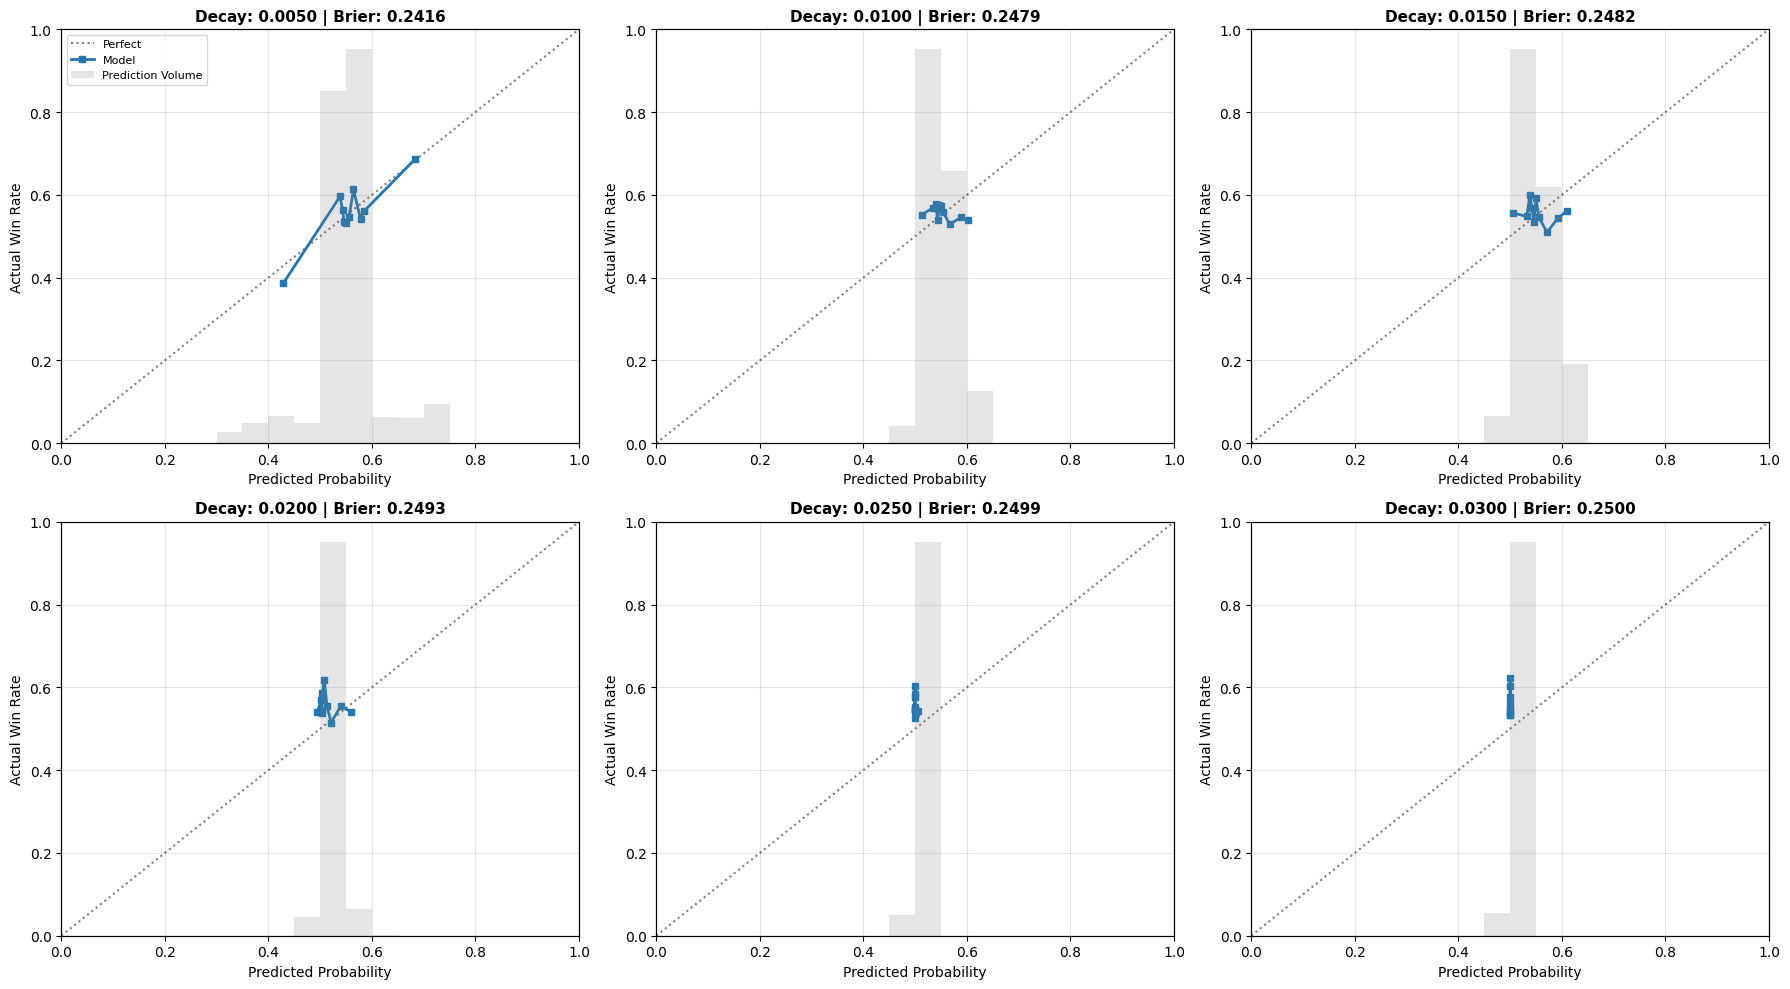


Decay Rate   | Brier Score  | ECE (Est.)   | Avg Confidence 
------------------------------------------------------------
0.0050       | 0.2416       | 0.0273       | 0.0721         
0.0100       | 0.2479       | 0.0313       | 0.0540         
0.0150       | 0.2482       | 0.0375       | 0.0552         
0.0200       | 0.2493       | 0.0461       | 0.0164         
0.0250       | 0.2499       | 0.0554       | 0.0009         
0.0300       | 0.2500       | 0.0648       | 0.0000         
------------------------------------------------------------
Optimal Decay (Lowest Brier): 0.0050


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# --- CONFIGURATION ---
# Define grid dimensions (e.g., 3 charts per row)
COLS = 3
n_plots = len(calibration_data)
ROWS = math.ceil(n_plots / COLS)

# Setup Figure
fig, axes = plt.subplots(ROWS, COLS, figsize=(18, 5 * ROWS))
axes = axes.flatten() # Flatten 2D grid to 1D array for easy looping

# Get sorted keys so we step through decay rates in order
sorted_decays = sorted(calibration_data.keys())

# --- PLOTTING LOOP ---
for i, decay in enumerate(sorted_decays):
    ax1 = axes[i]
    
    # Extract Data
    data = calibration_data[decay]
    probs = data['probs']
    actuals = data['actuals']
    
    # 1. Calculate Statistics
    brier = brier_score_loss(actuals, probs)
    prob_true, prob_pred = calibration_curve(actuals, probs, n_bins=10, strategy='quantile')
    
    # 2. Plot Histogram (Volume/Density) on Secondary Axis
    # This shows "Where are my predictions clustering?"
    ax2 = ax1.twinx()
    ax2.hist(probs, range=(0, 1), bins=20, histtype='stepfilled', 
             color='gray', alpha=0.2, label='Prediction Volume')
    ax2.set_yticks([]) # Hide y-ticks for histogram to keep it clean
    
    # 3. Plot Calibration Curve on Primary Axis
    ax1.plot([0, 1], [0, 1], "k:", label="Perfect", alpha=0.5) # Diagonal
    ax1.plot(prob_pred, prob_true, "s-", linewidth=2, color='tab:blue', 
             markersize=5, label=f"Model")
    
    # 4. Formatting
    ax1.set_title(f"Decay: {decay:.4f} | Brier: {brier:.4f}", fontsize=11, fontweight='bold')
    ax1.set_xlabel("Predicted Probability")
    ax1.set_ylabel("Actual Win Rate")
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Only add legend to the first plot to save space
    if i == 0:
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=8)

# Hide any empty subplots if n_plots is not a perfect multiple of COLS
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- NUMERICAL ANALYSIS TABLE ---
print("\n" + "="*60)
print(f"{'Decay Rate':<12} | {'Brier Score':<12} | {'ECE (Est.)':<12} | {'Avg Confidence':<15}")
print("-" * 60)

best_brier = float('inf')
best_decay = None

for decay in sorted_decays:
    data = calibration_data[decay]
    p = data['probs']
    a = data['actuals']
    
    # Metrics
    brier = brier_score_loss(a, p)
    prob_true, prob_pred = calibration_curve(a, p, n_bins=10, strategy='quantile')
    ece = np.mean(np.abs(prob_true - prob_pred))
    avg_conf = np.mean(np.abs(p - 0.5))
    
    if brier < best_brier:
        best_brier = brier
        best_decay = decay
    
    print(f"{decay:<12.4f} | {brier:<12.4f} | {ece:<12.4f} | {avg_conf:<15.4f}")

print("-" * 60)
print(f"Optimal Decay (Lowest Brier): {best_decay:.4f}")

In [15]:
# 1. PREPARE DATA STREAM
# We ensure the data is sorted by date so we don't peek into the future
# 1. PREPARE DATA STREAM
# We ensure the data is sorted by date so we don't peek into the future
full_stream = nba_model_ready.sort_values(['game_date', 'id']).reset_index(drop=True)
full_stream['game_date'] = pd.to_datetime(full_stream['game_date'])

# Convert features to a highly optimized Numpy array for speed
full_values = np.ascontiguousarray(full_stream[feature_cols].values.astype('float32'))
full_labels = full_stream['home_winner'].astype(int).values
full_dates = full_stream['game_date'].values

# 2. DEFINE START POINT
# We start predicting games from the 2023 season onwards
start_index = full_stream[full_stream['season'] < 2023].shape[0]

print(f"Training on first {start_index} games. Predicting the remaining {len(full_stream) - start_index}...")

# 3. INITIALIZE TRACKING
predictions, actuals, probs, game_num = [], [], [], [] # Added game_num for alignment
xgb_preds, xgb_actuals = [], [] # For confident bets only
base_fav_correct = 0
total_games_tracked = 0

print(f"Starting Dynamic Benchmark Loop...")
start_time = time.time()

# 4. MAIN LOOP (Dynamic 80/20 Split)
for i in range(start_index, len(full_stream), BATCH_SIZE):
    
    # --- A. DEFINE TEMPORAL SPLIT ---
    # We use data from 0 to 'i' (today).
    # Split: 85% Train (Oldest) / 15% Validation (Most Recent)
    train_cut = int(i * 0.85) 
    
    # --- B. CALCULATE WEIGHTS ---
    # Calculate weights for ALL available history (0 to i) relative to today
    current_prediction_date = full_dates[i]
    days_diff = (current_prediction_date - full_dates[:i]).astype('timedelta64[D]').astype(int)
    all_weights = np.exp(-DECAY_RATE * days_diff)
    
    # --- C. CREATE DMATRICES ---
    # Train Set (First 85%)
    dtrain = xgb.DMatrix(
        full_values[:train_cut], 
        label=full_labels[:train_cut], 
        weight=all_weights[:train_cut]
    )
    
    # Validation Set (Recent 15%) - This prevents overfitting
    dvalid = xgb.DMatrix(
        full_values[train_cut:i], 
        label=full_labels[train_cut:i], 
        weight=all_weights[train_cut:i]
    )
    
    # --- D. TRAIN WITH EARLY STOPPING ---
    # Train up to 1000 rounds, but STOP if validation error doesn't improve for 20 rounds
    bst = xgb.train(
        params, 
        dtrain, 
        num_boost_round=1000, 
        evals=[(dtrain, 'train'), (dvalid, 'eval')],
        early_stopping_rounds=20,
        verbose_eval=False
    )
    
    # --- E. PREDICT ---
    end_idx = min(i + BATCH_SIZE, len(full_stream))
    dtest = xgb.DMatrix(full_values[i:end_idx])
    
    # CRITICAL: Use only the "best" trees found during training
    batch_probs = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
    
    # --- F. EVALUATE ---
    for idx, p in enumerate(batch_probs):
        global_idx = i + idx
        actual_outcome = full_labels[global_idx]
        
        # --- DEAD ZONE FILTER ---
        # Only append and track if OUTSIDE the 0.45 - 0.55 range
        if p > 0.5 or p <= 0.5:
            
            # 1. Append to main analysis lists
            predictions.append(1 if p > 0.5 else 0)
            actuals.append(actual_outcome)
            probs.append(p)
            game_num.append(i + idx - start_index)
            
            # 2. Track Baseline (Only for these valid games)
            h_prob = full_stream.loc[global_idx, 'home_market_prob']
            a_prob = full_stream.loc[global_idx, 'away_market_prob']
            fav_pred = 1 if h_prob > a_prob else 0
            if fav_pred == actual_outcome:
                base_fav_correct += 1
            
            total_games_tracked += 1
            
            # 3. XGBOOST CONFIDENT BETS (Subset of valid games)
            if p > CONFIDENCE_THRESHOLD_HIGH:
                xgb_preds.append(1)
                xgb_actuals.append(actual_outcome)
            elif p < CONFIDENCE_THRESHOLD_LOW:
                xgb_preds.append(0)
                xgb_actuals.append(actual_outcome)

    # --- GARBAGE COLLECTION ---
    del dtrain, dvalid, dtest, bst
    gc.collect()

    # Progress Log (Every 10 batches)
    if i % 10 == 0 and len(xgb_preds) > 0:
        elapsed = time.time() - start_time
        acc = accuracy_score(xgb_actuals, xgb_preds)
        print(f"Batch {i}: XGB Confident Acc: {acc:.2%} ({len(xgb_preds)} bets) - {elapsed:.1f}s")

# 5. FINAL REPORT
print("\n--- FINAL RESULTS ---")
print(f"Total Games Analyzed (Excluding Toss-ups): {total_games_tracked}")

if total_games_tracked > 0:
    print(f"Vegas Favorite Baseline Accuracy: {base_fav_correct/total_games_tracked:.2%}")

if len(xgb_preds) > 0:
    final_acc = accuracy_score(xgb_actuals, xgb_preds)
    print(f"XGBoost Model (Confident) Accuracy: {final_acc:.2%} on {len(xgb_preds)} bets")
else:
    print("XGBoost Model made no bets meeting the confidence threshold.")

Training on first 20486 games. Predicting the remaining 4761...
Starting Dynamic Benchmark Loop...


ValueError: operands could not be broadcast together with shapes (15,) (20486,) 

ValueError: y_true takes value in {} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

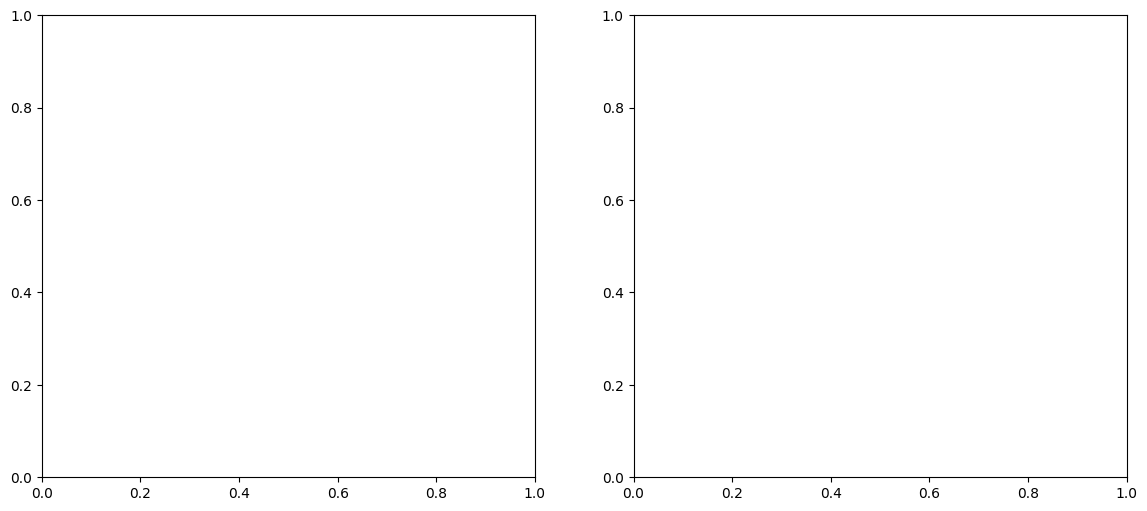

In [16]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Convert to arrays if not already
probs_array = np.array(probs)
actuals_array = np.array(actuals)

# Create figure with multiple visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== PLOT 1: Traditional Calibration Curve with More Bins =====
ax1 = axes[0]

# Use more bins and quantile strategy for better distribution
fraction_of_positives, mean_predicted_value = calibration_curve(
    actuals_array, 
    probs_array, 
    n_bins=15,  # More bins for granularity
    strategy='quantile'  # Each bin has roughly equal number of samples
)

ax1.plot(mean_predicted_value, fraction_of_positives, 'o-', 
         linewidth=2, markersize=8, label='XGBoost Model')
ax1.plot([0, 1], [0, 1], '--', color='orange', linewidth=2, 
         label='Perfectly Calibrated', alpha=0.7)

# Add count labels to each point
for i, (x, y) in enumerate(zip(mean_predicted_value, fraction_of_positives)):
    # Count samples in this bin
    if i < len(mean_predicted_value) - 1:
        mask = (probs_array >= mean_predicted_value[i]) & (probs_array < mean_predicted_value[i+1])
    else:
        mask = probs_array >= mean_predicted_value[i]
    count = mask.sum()
    ax1.annotate(f'n={count}', (x, y), textcoords="offset points", 
                xytext=(0,8), ha='center', fontsize=8, alpha=0.7)

ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
ax1.set_ylabel('Fraction of Positives (Actual Win Rate)', fontsize=12)
ax1.set_title('Calibration Curve (Quantile Binning)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.05, 1.05])

# ===== PLOT 2: Histogram + Calibration by Fixed Bins =====
ax2 = axes[1]

# Create fixed bins
bins = np.linspace(0, 1, 21)  # 20 bins of width 0.05
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calculate actual win rate and count per bin
bin_accs = []
bin_counts = []

for i in range(len(bins) - 1):
    mask = (probs_array >= bins[i]) & (probs_array < bins[i+1])
    count = mask.sum()
    bin_counts.append(count)
    
    if count > 0:
        acc = actuals_array[mask].mean()
        bin_accs.append(acc)
    else:
        bin_accs.append(np.nan)

# Plot histogram (bars)
ax2_hist = ax2.twinx()
ax2_hist.bar(bin_centers, bin_counts, width=0.045, alpha=0.3, 
             color='gray', label='# Predictions')
ax2_hist.set_ylabel('Number of Predictions', fontsize=11, color='gray')
ax2_hist.tick_params(axis='y', labelcolor='gray')

# Plot calibration line
valid_mask = ~np.isnan(bin_accs)
ax2.plot(bin_centers[valid_mask], np.array(bin_accs)[valid_mask], 
         'o-', linewidth=2, markersize=8, color='#1f77b4', label='Actual Win Rate')
ax2.plot([0, 1], [0, 1], '--', color='orange', linewidth=2, 
         label='Perfect Calibration', alpha=0.7)

ax2.set_xlabel('Predicted Probability', fontsize=12)
ax2.set_ylabel('Actual Win Rate', fontsize=12)
ax2.set_title('Calibration with Sample Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('calibration_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== NUMERICAL SUMMARY =====
print("\n" + "="*60)
print("CALIBRATION ANALYSIS BY PROBABILITY RANGE")
print("="*60)

ranges = [
    (0.0, 0.3, "Very Low Confidence"),
    (0.3, 0.45, "Low Confidence"),
    (0.45, 0.55, "Toss-up"),
    (0.55, 0.7, "Moderate Confidence"),
    (0.7, 0.85, "High Confidence"),
    (0.85, 0.95, "Very High Confidence"),
    (0.95, 1.0, "Extreme Confidence")
]

for low, high, label in ranges:
    mask = (probs_array >= low) & (probs_array <= high)
    count = mask.sum()
    
    if count > 0:
        actual_rate = actuals_array[mask].mean()
        pred_mean = probs_array[mask].mean()
        calibration_error = abs(actual_rate - pred_mean)
        
        print(f"\n{label:25s} [{low:.2f} - {high:.2f}]")
        print(f"  Count:              {count:4d}")
        print(f"  Mean Predicted:     {pred_mean:.3f}")
        print(f"  Actual Win Rate:    {actual_rate:.3f}")
        print(f"  Calibration Error:  {calibration_error:.3f}")
    else:
        print(f"\n{label:25s} [{low:.2f} - {high:.2f}]")
        print(f"  No predictions in this range")

print("\n" + "="*60)

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
import time
import gc

# --- CONFIGURATION (ADJUSTABLE) ---
BATCH_SIZE = 10           # Games processed at once
BANKROLL = 100000         # Starting money

# --- STAKING STRATEGY ---
FLAT_BET_PCT = 0.03       # % of bankroll for Favorites
KELLY_FRACTION = 0.10     # Fraction of Kelly for Underdogs
MAX_WAGER_PCT = 0.05      # Hard cap on any single bet

# --- FILTERS ---
MAX_MODEL_PROB = 0.75     # The "Cliff" - Don't bet if model is too confident
PROB_FLOOR_FAV = 0.70     # Only bet Favorites if model > 70%
PROB_FLOOR_DOG = 0.425     # The floor for Underdogs (allows 44% bets)
MIN_EDGE = 0.02           # Minimum edge required

# ### NEW: MARKET PROBABILITY FLOOR ###
# If the market thinks a team has < 25% chance (odds > +300), DO NOT BET.
# This prevents betting on "Long Shots" where variance is highest.
MARKET_PROB_FLOOR = 0.31  

# --- MODEL PARAMS ---
# params = {'objective': 'binary:logistic', 'tree_method': 'hist', 'eval_metric': 'logloss'} 
DECAY_RATE = 0.055         


# 1. PREPARE DATA STREAM
# Ensure data is sorted by date so we don't peek into the future
full_stream = nba_model_ready.sort_values(['game_date', 'id']).reset_index(drop=True)
full_stream['game_date'] = pd.to_datetime(full_stream['game_date'])

# Convert features to a highly optimized Numpy array for speed
full_values = np.ascontiguousarray(full_stream[feature_cols].values.astype('float32'))
full_labels = full_stream['home_winner'].astype(int).values
full_dates = full_stream['game_date'].values



# Initialize
bets_log_final = [] 
current_bankroll = BANKROLL
total_start_time = time.time()
start_index = full_stream[full_stream['season'] < 2023].shape[0]



print(f"Starting 'Sniper' Strategy...")
print(f"   > Market Floor: {MARKET_PROB_FLOOR*100}% (No bets on < {MARKET_PROB_FLOOR*100}% market prob)")

# --- MAIN LOOP ---
for i in range(start_index, len(full_stream), BATCH_SIZE):
    # --- A. TEMPORAL SPLIT ---
    current_prediction_date = full_dates[i]
    split_idx = int(i * 0.85)
    
    X_train, y_train = full_values[0:split_idx], full_labels[0:split_idx]
    X_eval, y_eval = full_values[split_idx:i], full_labels[split_idx:i]
    
    train_dates = full_dates[0:split_idx]
    eval_dates = full_dates[split_idx:i]
    
    # --- B. WEIGHTS ---
    w_train = np.exp(-DECAY_RATE * ((current_prediction_date - train_dates).astype('timedelta64[D]').astype(int) / 7))
    w_eval = np.exp(-DECAY_RATE * ((current_prediction_date - eval_dates).astype('timedelta64[D]').astype(int) / 7))
    
    # --- C. TRAIN ---
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
    deval = xgb.DMatrix(X_eval, label=y_eval, weight=w_eval)
    
    bst = xgb.train(
        params, 
        dtrain, 
        num_boost_round=1000, 
        evals=[(dtrain,'train'),(deval,'eval')],
        early_stopping_rounds=20, 
        verbose_eval=False
    )
    current_best_iter = bst.best_iteration
    
    # --- D. PREDICT ---
    end_idx = min(i + BATCH_SIZE, len(full_stream))
    dtest = xgb.DMatrix(full_values[i : end_idx])
    batch_probs = bst.predict(dtest, iteration_range=(0, current_best_iter + 1))

    # --- E. EVALUATE & BET ---
    for idx, p in enumerate(batch_probs):
        global_idx = i + idx
        actual_outcome = full_labels[global_idx]
        
        # 1. SETUP BOTH SIDES
        prob_home = p
        prob_away = 1.0 - p
        
        market_prob_home = full_stream.loc[global_idx, 'home_market_prob']
        market_prob_away = full_stream.loc[global_idx, 'away_market_prob']
        
        edge_home = prob_home - market_prob_home
        edge_away = prob_away - market_prob_away

        # 2. SELECT TARGET (Value Hunting)
        target_side = None
        
        if edge_home > edge_away and edge_home > 0:
            target_side = 'Home'
            my_prob = prob_home
            market_prob = market_prob_home
            edge = edge_home
            outcome_win = (actual_outcome == 1)
        
        elif edge_away > edge_home and edge_away > 0:
            target_side = 'Away'
            my_prob = prob_away
            market_prob = market_prob_away
            edge = edge_away
            outcome_win = (actual_outcome == 0)
            
        if target_side is None:
            continue

        # 3. GET ODDS & STATUS
        decimal_odds = 1.0 / market_prob if market_prob > 0 else 0
        is_underdog = (decimal_odds >= 2.0)

        should_bet = False
        bet_type = "None"
        
        # 4. APPLY SNIPER FILTERS
        
        # ### NEW CHECK: MARKET FLOOR ###
        # If the market thinks this happens less than 25% of the time, SKIP IT.
        if market_prob < MARKET_PROB_FLOOR:
            should_bet = False
        
        # Standard Checks
        elif my_prob <= MAX_MODEL_PROB:
            
            # Scenario A: False Underdog
            if is_underdog and my_prob >= PROB_FLOOR_DOG:
                if edge >= MIN_EDGE:
                    should_bet = True
                    bet_type = "False Underdog"
            
            # Scenario B: Strong Favorite
            elif not is_underdog and my_prob >= PROB_FLOOR_FAV:
                if edge >= MIN_EDGE:
                    should_bet = True
                    bet_type = "Strong Favorite"

        # 5. EXECUTE BET
        if should_bet and decimal_odds > 1.0:
            stake = 0.0
            
            if bet_type == "False Underdog":
                b_odds = decimal_odds - 1
                q_prob = 1 - my_prob
                if b_odds > 0:
                    kelly_pct = ((b_odds * my_prob) - q_prob) / b_odds
                else:
                    kelly_pct = 0
                bet_pct = min(max(kelly_pct * KELLY_FRACTION, 0), MAX_WAGER_PCT)
                stake = current_bankroll * bet_pct
            
            elif bet_type == "Strong Favorite":
                #stake = current_bankroll * FLAT_BET_PCT
                stake = 0.1
            
            if stake > 0.1:
                if outcome_win:
                    profit = stake * (decimal_odds - 1)
                else:
                    profit = -stake
                
                current_bankroll += profit
                
                bets_log_final.append({
                    'Game_ID': global_idx,
                    'Date': full_stream.loc[global_idx, 'game_date'],
                    'Type': target_side,
                    'My_Prob': round(my_prob, 3),
                    'Market_Prob': round(market_prob, 3),
                    'Edge': round(edge, 3),
                    'Odds': round(decimal_odds, 2),
                    'Stake': round(stake, 2),
                    'Result': 'Win' if outcome_win else 'Loss',
                    'Profit': round(profit, 2),
                    'Bankroll': round(current_bankroll, 2),
                    'Bet_Type': bet_type
                })

    # Cleanup
    del dtrain, deval, dtest, bst, w_train, w_eval
    if i % 50 == 0: gc.collect()
    
    # Log Progress
    if (i - start_index) % 100 == 0:
        elapsed = time.time() - total_start_time
        print(f"Game {i}: {elapsed/60:.1f}m | Bets: {len(bets_log_final)} | PnL: ${current_bankroll - BANKROLL:.0f}")

# --- REPORTING ---
print(f"\nTotal Time: {(time.time() - total_start_time)/60:.2f} minutes")

if len(bets_log_final) > 0:
    df_res = pd.DataFrame(bets_log_final)
    total_wagered = df_res['Stake'].sum()
    
    print("\n=== SNIPER STRATEGY RESULTS (FINAL) ===")
    print(f"Total Bets:    {len(bets_log_final)}")
    print(f"Win Rate:      {len(df_res[df_res['Result']=='Win']) / len(df_res):.2%}")
    print(f"Total Profit:  ${current_bankroll - BANKROLL:.2f}")
    if total_wagered > 0:
        print(f"ROI:           {((current_bankroll - BANKROLL) / total_wagered) * 100:.2f}%")
    print(f"Final Bankroll:${current_bankroll:.2f}")
    
    print("\n--- Performance by Category ---")
    print(df_res.groupby('Bet_Type')[['Stake', 'Profit', 'Result']].agg({
        'Stake': 'count', 
        'Profit': 'sum',
        'Result': lambda x: f"{(x=='Win').mean():.1%}"
    }).rename(columns={'Stake': 'Count', 'Result': 'Win %'}))
else:
    print("No bets found.")

Starting 'Sniper' Strategy...
   > Market Floor: 31.0% (No bets on < 31.0% market prob)
Game 20486: 0.0m | Bets: 2 | PnL: $-2832
Game 20586: 0.0m | Bets: 47 | PnL: $42258
Game 20686: 0.0m | Bets: 99 | PnL: $23821
Game 20786: 0.1m | Bets: 144 | PnL: $5781
Game 20886: 0.1m | Bets: 193 | PnL: $-1575
Game 20986: 0.1m | Bets: 240 | PnL: $21391
Game 21086: 0.1m | Bets: 297 | PnL: $435
Game 21186: 0.1m | Bets: 343 | PnL: $8601
Game 21286: 0.1m | Bets: 393 | PnL: $15458
Game 21386: 0.2m | Bets: 446 | PnL: $10562
Game 21486: 0.2m | Bets: 506 | PnL: $7155
Game 21586: 0.2m | Bets: 562 | PnL: $-777
Game 21686: 0.2m | Bets: 608 | PnL: $-6590
Game 21786: 0.2m | Bets: 655 | PnL: $3810
Game 21886: 0.2m | Bets: 713 | PnL: $-14811
Game 21986: 0.3m | Bets: 766 | PnL: $-23323
Game 22086: 0.3m | Bets: 812 | PnL: $-31179
Game 22186: 0.3m | Bets: 861 | PnL: $-37410
Game 22286: 0.3m | Bets: 909 | PnL: $-34520
Game 22386: 0.3m | Bets: 945 | PnL: $-10824
Game 22486: 0.3m | Bets: 989 | PnL: $-19350
Game 22586: 0

In [18]:
import numpy as np
import pandas as pd
import xgboost as xgb
import time
import gc
from sklearn.isotonic import IsotonicRegression

# ============================================================
# 0) Market helpers (nba_model_ready has implied probs only)
# ============================================================
def vig_free_from_implied(p_imp_home: float, p_imp_away: float) -> tuple[float, float]:
    """Normalize implied probs so they sum to 1 (remove vig for edge detection)."""
    try:
        p_imp_home = float(p_imp_home)
        p_imp_away = float(p_imp_away)
    except Exception:
        return np.nan, np.nan

    if not (0.0 < p_imp_home < 1.0 and 0.0 < p_imp_away < 1.0):
        return np.nan, np.nan

    s = p_imp_home + p_imp_away
    if s <= 0:
        return np.nan, np.nan

    return p_imp_home / s, p_imp_away / s

def implied_prob_to_decimal(p_imp: float) -> float:
    """Decimal payout odds implied by the line (vig-included)."""
    try:
        p_imp = float(p_imp)
    except Exception:
        return np.nan
    if not (0.0 < p_imp < 1.0):
        return np.nan
    return 1.0 / p_imp

def kelly_fraction(p: float, dec_odds: float) -> float:
    """Kelly fraction for decimal odds."""
    b = dec_odds - 1.0
    if b <= 0:
        return 0.0
    f = (b * p - (1.0 - p)) / b
    return max(0.0, f)

# ============================================================
# 1) Strategy configuration (UNDERDOGS ONLY)
# ============================================================
BATCH_SIZE = 10
BANKROLL0 = 100000

# staking (underdogs)
KELLY_FRACTION_DOG = 0.10     # fractional Kelly multiplier
MAX_WAGER_PCT = 0.05          # hard cap
# selection thresholds (RAW only)
MIN_EDGE = 0.01
MARKET_PROB_FLOOR = 0.31      # skip extreme longshots (vig-free market prob, chosen side)
PROB_FLOOR_DOG = 0.45         # raw prob threshold for underdogs
UNDERDOG_ODDS_FLOOR = 2    # avoid short "underdogs" that have been losing money

# mild numerical gate
MAX_MODEL_PROB = 0.98

# model / time weighting
DECAY_RATE = 0.055
EVAL_WINDOW = 800
CALIB_WINDOW = 600
MIN_EVAL = 200

# market columns (implied probs, vig-included)
HOME_IMP_COL = "home_market_prob"
AWAY_IMP_COL = "away_market_prob"

# ============================================================
# 2) Prepare stream (expects nba_model_ready + feature_cols)
# ============================================================
required_cols = ["game_date", "home_winner", "season", HOME_IMP_COL, AWAY_IMP_COL]
missing = [c for c in required_cols if c not in nba_model_ready.columns]
if missing:
    raise ValueError(f"nba_model_ready is missing required columns: {missing}")

full_stream = nba_model_ready.sort_values(["game_date", "id"]).reset_index(drop=True)
full_stream["game_date"] = pd.to_datetime(full_stream["game_date"])

X_all = np.ascontiguousarray(full_stream[feature_cols].values.astype("float32"))
y_all = full_stream["home_winner"].astype(int).values
dates_all = full_stream["game_date"].values

start_index = full_stream[full_stream["season"] < 2024].shape[0]
print(f"Training on first {start_index} games. Predicting remaining {len(full_stream) - start_index}...")

# ============================================================
# 3) XGBoost params
# ============================================================
params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "eval_metric": "logloss",
    "max_depth": 4,
    "eta": 0.03,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "min_child_weight": 5,
    "lambda": 1.0,
}

NUM_BOOST_ROUND = 4000
EARLY_STOPPING = 50

# ============================================================
# 4) Loop: RAW selection, CAL sizing, UNDERDOGS ONLY
# ============================================================
bankroll = float(BANKROLL0)
bets_log = []
pred_log = []

t0 = time.time()
print("Starting UNDERDOG-ONLY loop (RAW-select / CAL-size + vig-free edge)...")

for i in range(start_index, len(full_stream), BATCH_SIZE):
    gc.collect()

    batch_end = min(i + BATCH_SIZE, len(full_stream))
    current_date = dates_all[i]

    eval_start = max(start_index, i - EVAL_WINDOW)
    train_end = eval_start
    if train_end <= 0 or (i - eval_start) < 50:
        continue

    X_train, y_train = X_all[:train_end], y_all[:train_end]
    X_eval, y_eval = X_all[eval_start:i], y_all[eval_start:i]

    train_dates = dates_all[:train_end]
    eval_dates = dates_all[eval_start:i]

    train_age_weeks = ((current_date - train_dates).astype("timedelta64[D]").astype(int) / 7.0)
    eval_age_weeks  = ((current_date - eval_dates ).astype("timedelta64[D]").astype(int) / 7.0)

    w_train = np.exp(-DECAY_RATE * train_age_weeks)
    w_eval  = np.exp(-DECAY_RATE * eval_age_weeks)

    dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
    deval  = xgb.DMatrix(X_eval,  label=y_eval,  weight=w_eval)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(deval, "eval")],
        early_stopping_rounds=EARLY_STOPPING,
        verbose_eval=False,
    )

    # calibration fit (short window)
    eval_probs_raw = model.predict(deval, iteration_range=(0, model.best_iteration + 1))
    if len(eval_probs_raw) > CALIB_WINDOW:
        eval_probs_cal = eval_probs_raw[-CALIB_WINDOW:]
        y_eval_cal = y_eval[-CALIB_WINDOW:]
    else:
        eval_probs_cal = eval_probs_raw
        y_eval_cal = y_eval

    do_calibrate = (len(eval_probs_cal) >= MIN_EVAL) and (np.unique(y_eval_cal).size == 2)

    calibrator = None
    if do_calibrate:
        ir = IsotonicRegression(out_of_bounds="clip")
        ir.fit(np.clip(eval_probs_cal, 1e-6, 1 - 1e-6), y_eval_cal)
        calibrator = ir

    # batch predictions
    X_batch = X_all[i:batch_end]
    dtest = xgb.DMatrix(X_batch)

    batch_probs_raw = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))
    if calibrator is not None:
        batch_probs_cal = calibrator.transform(np.clip(batch_probs_raw, 1e-6, 1 - 1e-6))
    else:
        batch_probs_cal = batch_probs_raw

    # per-game decisions
    for j in range(i, batch_end):
        if bankroll <= 0:
            break

        row = full_stream.iloc[j]

        p_home_raw = float(batch_probs_raw[j - i])
        p_home_cal = float(batch_probs_cal[j - i])

        if not (0.0 < p_home_raw < 1.0 and 0.0 < p_home_cal < 1.0):
            continue
        if p_home_raw > MAX_MODEL_PROB or p_home_raw < (1.0 - MAX_MODEL_PROB):
            continue

        try:
            p_imp_home = float(row[HOME_IMP_COL])
            p_imp_away = float(row[AWAY_IMP_COL])
        except Exception:
            continue

        p_mkt_home, p_mkt_away = vig_free_from_implied(p_imp_home, p_imp_away)
        if np.isnan(p_mkt_home) or np.isnan(p_mkt_away):
            continue

        dec_odds_home = implied_prob_to_decimal(p_imp_home)
        dec_odds_away = implied_prob_to_decimal(p_imp_away)
        if np.isnan(dec_odds_home) or np.isnan(dec_odds_away):
            continue

        # edges (raw selection)
        edge_home = p_home_raw - p_mkt_home
        edge_away = (1.0 - p_home_raw) - p_mkt_away
        if edge_home <= 0 and edge_away <= 0:
            continue

        # choose side by raw edge
        if edge_home >= edge_away:
            side = "HOME"
            edge = edge_home
            p_mkt = p_mkt_home
            dec_odds = dec_odds_home
            p_raw_side = p_home_raw
            p_cal_side = p_home_cal
        else:
            side = "AWAY"
            edge = edge_away
            p_mkt = p_mkt_away
            dec_odds = dec_odds_away
            p_raw_side = 1.0 - p_home_raw
            p_cal_side = 1.0 - p_home_cal

        # UNDERDOG ONLY filter
        if dec_odds < 2.0:
            continue

        # protect your underdog region (avoid short underdogs)
        if dec_odds < UNDERDOG_ODDS_FLOOR:
            continue

        # selection filters (raw only)
        if edge < MIN_EDGE:
            continue
        if p_mkt < MARKET_PROB_FLOOR:
            continue
        if p_raw_side < PROB_FLOOR_DOG:
            continue

        # sizing (cal only)
        f_kelly = kelly_fraction(p_cal_side, dec_odds)
        stake_pct = min(MAX_WAGER_PCT, KELLY_FRACTION_DOG * f_kelly)
        stake = bankroll * stake_pct
        if stake <= 0:
            continue

        # settle
        y_true = int(row["home_winner"])
        won = (y_true == 1) if side == "HOME" else (y_true == 0)

        profit = stake * (dec_odds - 1.0) if won else -stake
        bankroll += profit

        bets_log.append({
            "game_date": row["game_date"],
            "id": row.get("id", np.nan),
            "Side": side,
            "Bet_Type": "False Underdog",
            "Stake": stake,
            "Decimal_Odds": dec_odds,
            "p_model_raw": p_raw_side,
            "p_model_cal": p_cal_side,
            "p_market_fair": p_mkt,
            "Edge_raw": edge,
            "Won": int(won),
            "Profit": profit,
            "Bankroll_After": bankroll,
        })

        pred_log.append({
            "game_date": row["game_date"],
            "id": row.get("id", np.nan),
            "p_home_raw": p_home_raw,
            "p_home_cal": p_home_cal,
            "p_mkt_home_fair": float(p_mkt_home),
            "p_mkt_away_fair": float(p_mkt_away),
            "edge_home_raw": float(edge_home),
            "edge_away_raw": float(edge_away),
        })

print(f"Done. Final bankroll: {bankroll:,.2f}  |  Bets: {len(bets_log)}  |  Runtime: {time.time() - t0:.1f}s")

bets_df = pd.DataFrame(bets_log)
pred_df = pd.DataFrame(pred_log)

# ============================================================
# 5) Audits / summaries
# ============================================================
if len(bets_df) > 0:
    top_edges = bets_df.reindex(bets_df["Edge_raw"].abs().sort_values(ascending=False).index).head(25)
    display(top_edges[[
        "game_date", "id", "Side", "Decimal_Odds",
        "p_model_raw", "p_model_cal", "p_market_fair", "Edge_raw",
        "Stake", "Won", "Profit", "Bankroll_After"
    ]])

if len(bets_df) > 0:
    print("\nUnderdog-only summary:")
    print(pd.Series({
        "Bets": len(bets_df),
        "WinRate": bets_df["Won"].mean(),
        "AvgOdds": bets_df["Decimal_Odds"].mean(),
        "AvgEdge": bets_df["Edge_raw"].mean(),
        "ROI": bets_df["Profit"].sum() / bets_df["Stake"].sum(),
        "Profit": bets_df["Profit"].sum()
    }))

    print("\nEdge bins (quick sanity check):")
    bets_df["edge_bin"] = pd.qcut(bets_df["Edge_raw"], 5, duplicates="drop")
    print(bets_df.groupby("edge_bin").agg(
        Bets=("Profit", "count"),
        WinRate=("Won", "mean"),
        AvgOdds=("Decimal_Odds", "mean"),
        ROI=("Profit", lambda x: x.sum() / bets_df.loc[x.index, "Stake"].sum()),
        Profit=("Profit", "sum")
    ))


Training on first 21807 games. Predicting remaining 3440...
Starting UNDERDOG-ONLY loop (RAW-select / CAL-size + vig-free edge)...


KeyboardInterrupt: 

In [19]:
bets_df.groupby("Bet_Type")["Decimal_Odds"].mean()


NameError: name 'bets_df' is not defined

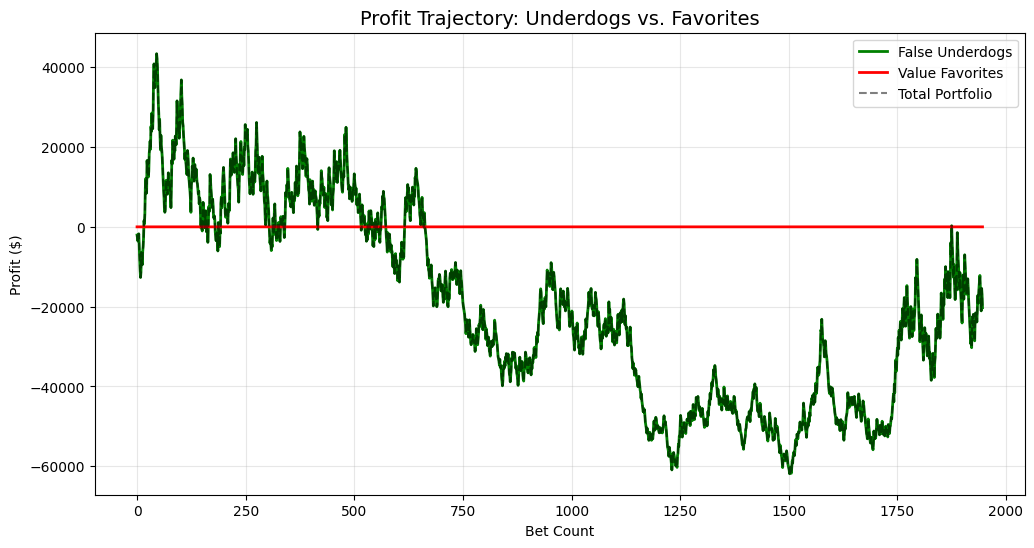


=== AUTOPSY: Why are Favorites Losing? ===
             Count Win_Rate Avg_Odds Total_Profit ROI
Conf_Bin                                             
(0.5, 0.55]      0      NaN      NaN           $0 NaN
(0.55, 0.6]      0      NaN      NaN           $0 NaN
(0.6, 0.65]      0      NaN      NaN           $0 NaN
(0.65, 0.7]      0      NaN      NaN           $0 NaN
(0.7, 0.75]      0      NaN      NaN           $0 NaN
(0.75, 0.8]      0      NaN      NaN           $0 NaN
(0.8, 0.85]      0      NaN      NaN           $0 NaN

=== DEEP DIVE: False Underdogs Stats ===
Average Odds Bet:  2.59
Actual Win Rate:   39.4%
Implied Win Rate:  38.6%
Edge realized:     0.8%

 Biggest Underdog Wins:
      Type  Odds  My_Prob   Profit
38    Home  3.10    0.560  9436.73
23    Home  3.10    0.565  8159.87
168   Home  3.20    0.555  8148.49
1873  Home  3.15    0.597  7773.64
193   Home  3.20    0.551  7521.26
1887  Home  3.20    0.591  7483.72
1875  Home  3.00    0.595  7288.90
187   Home  3.15    0.558

/var/folders/x3/2h269p1576s293vgwkccn0zm0000gn/T/ipykernel_63676/1119209345.py:45: RuntimeWarning: invalid value encountered in scalar divide
  ROI=('Profit', lambda x: x.sum() / favs.loc[x.index, 'Stake'].sum())


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_betting_history(bets_log):
    if not bets_log:
        print("No bets to analyze.")
        return

    # 1. Convert to DataFrame
    df = pd.DataFrame(bets_log)
    df['Cumulative_Profit'] = df['Profit'].cumsum()
    
    # 2. Cumulative Profit Chart (The "Tale of Two Strategies")
    plt.figure(figsize=(12, 6))
    
    # Create separate cumulative lines
    df['Profit_Dog'] = df.apply(lambda x: x['Profit'] if x['Bet_Type'] == 'False Underdog' else 0, axis=1)
    df['Profit_Fav'] = df.apply(lambda x: x['Profit'] if x['Bet_Type'] == 'Strong Favorite' else 0, axis=1)
    
    plt.plot(df.index, df['Profit_Dog'].cumsum(), label='False Underdogs', color='green', linewidth=2)
    plt.plot(df.index, df['Profit_Fav'].cumsum(), label='Value Favorites', color='red', linewidth=2)
    plt.plot(df.index, df['Cumulative_Profit'], label='Total Portfolio', color='black', linestyle='--', alpha=0.5)
    
    plt.title('Profit Trajectory: Underdogs vs. Favorites', fontsize=14)
    plt.xlabel('Bet Count')
    plt.ylabel('Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. The "Favorite" Autopsy: Why are we losing?
    # We group favorites by Model Confidence to find the "Leak Zone"
    print("\n=== AUTOPSY: Why are Favorites Losing? ===")
    favs = df[df['Bet_Type'] == 'Strong Favorite'].copy()
    
    # Create 5% Probability Bins
    favs['Conf_Bin'] = pd.cut(favs['My_Prob'], bins=np.arange(0.50, 0.90, 0.05))
    
    analysis = favs.groupby('Conf_Bin', observed=False).agg(
        Count=('Stake', 'count'),
        Win_Rate=('Result', lambda x: (x=='Win').mean()),
        Avg_Odds=('Odds', 'mean'),
        Total_Profit=('Profit', 'sum'),
        ROI=('Profit', lambda x: x.sum() / favs.loc[x.index, 'Stake'].sum())
    )
    
    print(analysis.to_string(formatters={
        'Win_Rate': '{:.1%}'.format,
        'Avg_Odds': '{:.2f}'.format,
        'Total_Profit': '${:,.0f}'.format,
        'ROI': '{:+.1%}'.format
    }))

    # 4. The "Underdog" Deep Dive: Are these lucky hits?
    print("\n=== DEEP DIVE: False Underdogs Stats ===")
    dogs = df[df['Bet_Type'] == 'False Underdog']
    
    print(f"Average Odds Bet:  {dogs['Odds'].mean():.2f}")
    print(f"Actual Win Rate:   {(dogs['Result']=='Win').mean():.1%}")
    print(f"Implied Win Rate:  {1/dogs['Odds'].mean():.1%}")
    print(f"Edge realized:     {(dogs['Result']=='Win').mean() - (1/dogs['Odds'].mean()):.1%}")
    
    # Top 5 Biggest Wins
    print("\n Biggest Underdog Wins:")
    print(dogs[dogs['Result']=='Win'].sort_values('Profit', ascending=False)[['Type', 'Odds', 'My_Prob', 'Profit']].head(20))

# --- EXECUTE ---
analyze_betting_history(bets_log_final)

In [22]:
df_log = pd.DataFrame(bets_log_final)
#dis_prob = df_log[df_log['Result'] == 'Loss'].sort_values('Edge', ascending=False)
dis_prob = df_log[df_log['My_Prob'] <= 0.44].sort_values('My_Prob', ascending=True)
#dis_prob = df_log.sort_values('Market_Prob', ascending=True)
dis_prob.head(25)

,Game_ID,Date,Type,My_Prob,Market_Prob,Edge,Odds,Stake,Result,Profit,Bankroll,Bet_Type
1741,24299,2025-05-06,Away,0.426,0.340,0.086,2.94,738.83,Win,1433.32,58062.11,False Underdog
1740,24298,2025-05-06,Away,0.426,0.336,0.091,2.98,752.34,Win,1489.63,56628.79,False Underdog
1120,22853,2024-03-22,Away,0.426,0.376,0.050,2.66,645.68,Win,1071.83,81894.20,False Underdog
1119,22852,2024-03-22,Away,0.426,0.317,0.108,3.15,1240.51,Win,2667.09,80822.37,False Underdog
1717,24248,2025-04-15,Away,0.426,0.340,0.086,2.94,640.50,Loss,-640.50,48680.82,False Underdog
1718,24249,2025-04-15,Away,0.426,0.323,0.103,3.10,741.96,Loss,-741.96,47938.86,False Underdog
1719,24251,2025-04-16,Away,0.426,0.345,0.081,2.90,592.68,Win,1126.09,49064.95,False Underdog
1720,24252,2025-04-19,Away,0.426,0.328,0.098,3.05,715.09,Loss,-715.09,48349.86,False Underdog
1721,24254,2025-04-19,Away,0.426,0.317,0.108,3.15,767.66,Loss,-767.66,47582.20,False Underdog
1722,24255,2025-04-19,Away,0.426,0.368,0.058,2.72,437.79,Win,753.00,48335.20,False Underdog


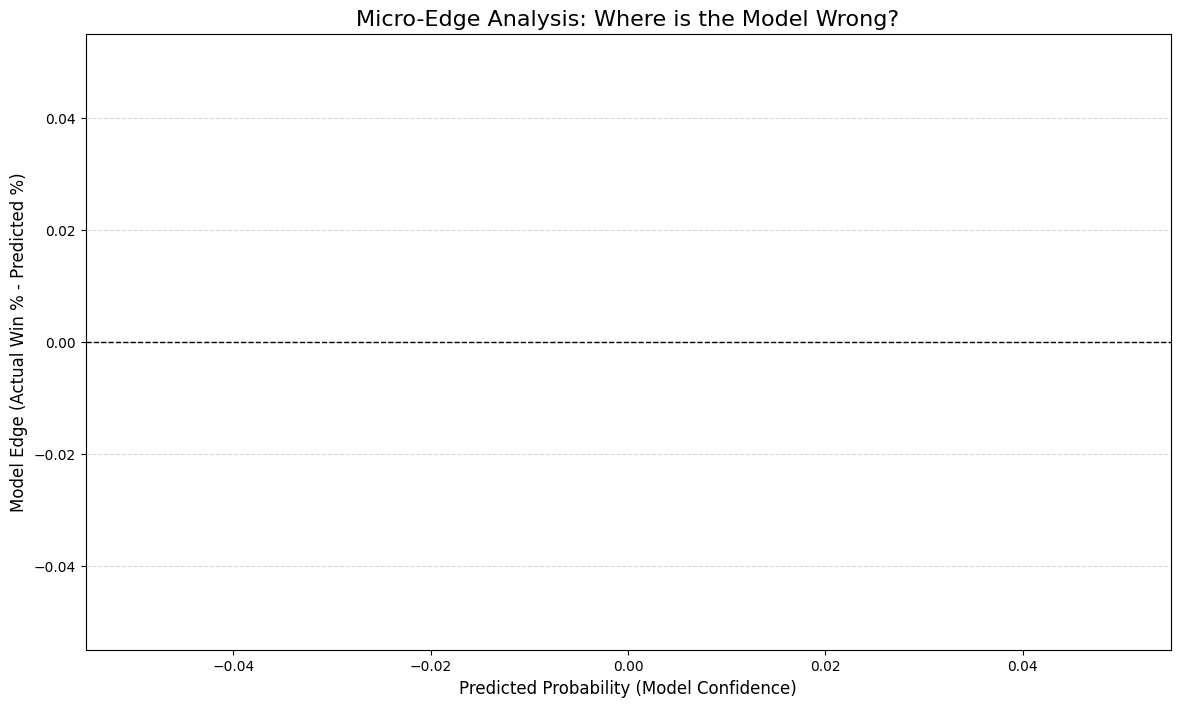


=== DETAILED 5% BIN ANALYSIS ===
Empty DataFrame
Columns: [bin, count, mean_pred, actual_win_rate, edge, action]
Index: []


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_fine_grained_calibration(y_true, y_prob, bin_width=0.05):
    """
    Analyzes calibration in strict 5% intervals to find micro-edges.
    """
    # 1. Create a DataFrame for analysis
    # Pandas handles Python lists (like your 'actuals' and 'probs') automatically
    df_cal = pd.DataFrame({'actual': y_true, 'prob': y_prob})
    
    # 2. Create Bins (0.00-0.05, 0.05-0.10, etc.)
    bins = np.arange(0, 1.0 + bin_width, bin_width)
    df_cal['bin'] = pd.cut(df_cal['prob'], bins=bins, include_lowest=True)
    
    # 3. Aggregate Stats by Bin
    cal_stats = df_cal.groupby('bin', observed=False).agg(
        count=('actual', 'count'),
        mean_pred=('prob', 'mean'),
        actual_win_rate=('actual', 'mean')
    ).reset_index()
    
    # 4. Calculate Edge & Standard Error
    # Edge = How much MORE the team wins compared to the prediction
    cal_stats['edge'] = cal_stats['actual_win_rate'] - cal_stats['mean_pred']
    
    # Standard Error (for confidence intervals)
    cal_stats['se'] = np.sqrt(
        (cal_stats['actual_win_rate'] * (1 - cal_stats['actual_win_rate'])) / cal_stats['count']
    )
    
    # 5. Filter out empty bins (Since you have a Dead Zone filter, the middle bins will be empty)
    cal_stats = cal_stats[cal_stats['count'] > 0]
    
    # 6. Define "Action" based on Edge
    def get_action(row):
        if row['count'] < 10: return "Low Sample"
        if row['edge'] > 0.03: return "BUY YES (Undervalued)" # Model is too pessimistic
        if row['edge'] < -0.03: return "SELL YES (Overvalued)" # Model is too optimistic
        return "Fair Value"
    
    cal_stats['action'] = cal_stats.apply(get_action, axis=1)

    # --- VISUALIZATION ---
    plt.figure(figsize=(14, 8))
    
    # Color logic: Green if edge > 0 (Value Buy), Red if edge < 0 (Value Sell)
    colors = ['green' if x > 0 else 'red' for x in cal_stats['edge']]
    
    plt.bar(
        cal_stats['mean_pred'], 
        cal_stats['edge'], 
        width=bin_width * 0.8, 
        color=colors, 
        alpha=0.7,
        edgecolor='black',
        label='Model Edge'
    )
    
    # Add error bars
    plt.errorbar(
        cal_stats['mean_pred'], 
        cal_stats['edge'], 
        yerr=cal_stats['se'], 
        fmt='none', 
        color='black', 
        capsize=3, 
        alpha=0.5
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel('Predicted Probability (Model Confidence)', fontsize=12)
    plt.ylabel('Model Edge (Actual Win % - Predicted %)', fontsize=12)
    plt.title('Micro-Edge Analysis: Where is the Model Wrong?', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Annotations
    for idx, row in cal_stats.iterrows():
        if row['count'] > 20 and abs(row['edge']) > 0.02:
            label_text = f"{row['edge']*100:+.1f}%"
            # Offset the text slightly above/below the bar
            y_pos = row['edge'] + (0.005 if row['edge'] > 0 else -0.015)
            plt.text(row['mean_pred'], y_pos, label_text, ha='center', fontsize=9, fontweight='bold')

    plt.show()

    # --- PRINT TABLE ---
    print("\n=== DETAILED 5% BIN ANALYSIS ===")
    display_cols = ['bin', 'count', 'mean_pred', 'actual_win_rate', 'edge', 'action']
    
    # Formatting for cleaner output
    print(cal_stats[display_cols].to_string(index=False, formatters={
        'mean_pred': '{:.3f}'.format,
        'actual_win_rate': '{:.3f}'.format,
        'edge': '{:+.3f}'.format
    }))
    
    return cal_stats

# --- EXECUTE ---
# Passing your specific lists from the loop: 'actuals' and 'probs'
stats = analyze_fine_grained_calibration(actuals, probs)

In [24]:
stats

,bin,count,mean_pred,actual_win_rate,edge,se,action
